# Analysis of `full_results.csv`

Dataset of image-generation prompts classified for **references to the past**.

Columns:
- `prompt` — the image-generation prompt
- `references_past` — yes/no classification
- `justification` — model justification for the classification
- `generation_time` — classification time in seconds

⚠️ The file is ~4.4 GB, so we start by previewing only the first rows rather than loading everything into memory.

In [2]:
import pandas as pd

DATA_PATH = "../code/data/results_mlx/full_results.csv"

## Preview: first rows

In [3]:
df_head = pd.read_csv(DATA_PATH, nrows=10)
df_head

,prompt,references_past,justification,generation_time
0,A portrait photo of a kangaroo wearing an oran...,no,**NO**: [The prompt references no historical p...,1.686503
1,inmates with cow heads inside a jailcell,no,"**[no]**: The prompt describes a fictional, su...",0.600779
2,"daguerrotype of a corgi astronaut on the moon,...",no,**[no]**: The prompt references **fictional/fa...,0.751850
3,totem animal tribal chaman vodoo mask feather ...,no,**NO**: [The prompt references modern fantasy ...,0.673003
4,p. cubensis,no,**NO**: [The prompt references a fictional or ...,1.001302
5,Illustration of a sugar skull day of the dead ...,no,**[no]**: The prompt references a modern cultu...,0.627786
6,two gnomes standing in front of a circular por...,no,**NO**: [The prompt references no historical p...,0.664437
7,"tall, security guard checks the bags of a worr...",no,**NO**: [The prompt describes a contemporary s...,0.609152
8,a colorful vibrant closeup portrait of a magic...,no,**NO**: [The prompt references modern artists ...,0.878007
9,mr clean mr clean mr clean and mike tyson laug...,no,**[no]**: The prompt references fictional char...,0.568702


In [3]:
df_head.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   prompt           10 non-null     str    
 1   references_past  10 non-null     str    
 2   justification    10 non-null     str    
 3   generation_time  10 non-null     float64
dtypes: float64(1), str(3)
memory usage: 3.8 KB


## 2. Pourquoi un prompt est-il exclu ? Analyse des justifications « no »

Chaque ligne a été classée par un modèle de langue. La colonne `justification` commence par un marqueur (`**NO**:`, `**[no]**:`, `**[yes/no]:`…) suivi de la raison invoquée.

Ici, on s'intéresse aux **raisons d'exclusion** : pourquoi le modèle décide qu'un prompt ne contient *pas* de référence au passé.

Méthode (le fichier fait ~4,4 Go, ~13,7 M de lignes → traitement en *streaming* par chunks) :
1. lecture par morceaux des seules colonnes `references_past` et `justification` ;
2. nettoyage du marqueur initial ;
3. comptage de **thèmes d'exclusion** par expressions régulières (un texte peut relever de plusieurs thèmes) ;
4. constitution d'un **échantillon aléatoire** (~200 000 justifications) pour l'analyse lexicale et la lecture qualitative.

In [4]:
import re
from collections import Counter

CHUNK_SIZE = 1_000_000
SAMPLE_FRAC = 0.015  # ~200 000 justifications « no » sur ~13 M

# marqueur initial : **NO**:, **[no]**:, **[yes/no]:** , etc.
prefix_re = re.compile(
    r"^\s*\*{0,2}\[?\s*(?:yes\s*/\s*no|no|yes)\s*\]?\s*\*{0,2}\s*:?\s*\*{0,2}\s*\[?\s*",
    re.IGNORECASE,
)

# typologie (ajustable) des raisons d'exclusion — un texte peut matcher plusieurs thèmes
themes = {
    "fictif / fantastique / surréel": r"fiction|fantasy|surreal|imaginar|myth|sci-?fi|futurist",
    "moderne / contemporain": r"modern|contemporary|present-day|current",
    "style seulement (vintage, rétro, esthétique)": r"stylistic|aesthetic|vintage|retro",
    "absence explicite d'élément historique": r"no (?:reference|historical|specific)|without (?:any )?historical|lacks (?:any )?historical",
    "abstrait / conceptuel": r"abstract|conceptual",
    "culture pop (jeu vidéo, film, anime, célébrités)": r"video ?game|anime|celebrit|pop[- ]?culture|movie|film|comic",
}
theme_res = {name: re.compile(rx, re.IGNORECASE) for name, rx in themes.items()}

class_counts = Counter()
theme_counts = Counter()
n_no = 0
n_no_unmatched = 0  # justifications « no » ne relevant d'aucun thème
samples = []

reader = pd.read_csv(DATA_PATH, usecols=["references_past", "justification"],
                     chunksize=CHUNK_SIZE)
for i, chunk in enumerate(reader):
    labels = chunk["references_past"].astype(str).str.strip().str.lower()
    class_counts.update(labels.value_counts().to_dict())

    just_no = (chunk.loc[labels == "no", "justification"]
               .astype(str)
               .str.replace(prefix_re, "", regex=True))
    n_no += len(just_no)

    matched = pd.Series(False, index=just_no.index)
    for name, rx in theme_res.items():
        hits = just_no.str.contains(rx)
        theme_counts[name] += int(hits.sum())
        matched |= hits
    n_no_unmatched += int((~matched).sum())

    samples.append(just_no.sample(frac=SAMPLE_FRAC, random_state=42 + i))
    print(f"chunk {i + 1}: {(i + 1) * CHUNK_SIZE:,} lignes lues", end="\r")

sample_no = pd.concat(samples, ignore_index=True)
print(f"\nTotal : {sum(class_counts.values()):,} lignes — "
      f"{class_counts['no']:,} « no », {class_counts['yes']:,} « yes » — "
      f"échantillon : {len(sample_no):,} justifications")

chunk 11: 11,000,000 lignes lues
Total : 10,670,393 lignes — 9,984,271 « no », 679,589 « yes » — échantillon : 149,765 justifications


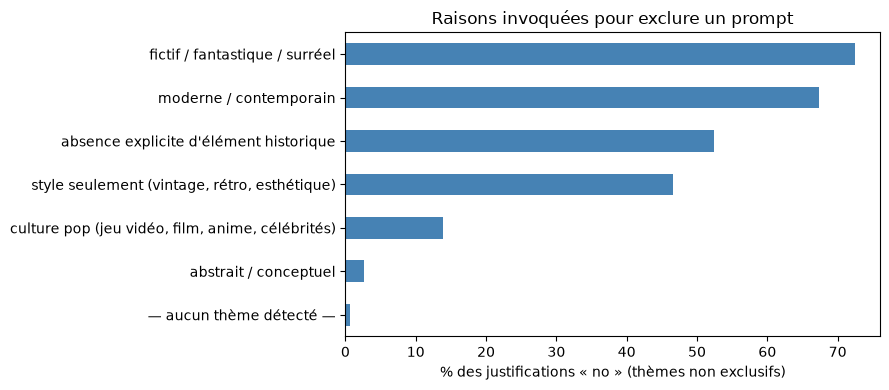

,nombre,part_des_no
fictif / fantastique / surréel,7232111.0,72.4
moderne / contemporain,6727133.0,67.4
absence explicite d'élément historique,5236445.0,52.4
"style seulement (vintage, rétro, esthétique)",4647907.0,46.6
"culture pop (jeu vidéo, film, anime, célébrités)",1388348.0,13.9
abstrait / conceptuel,260299.0,2.6
— aucun thème détecté —,73203.0,0.7


In [5]:
import matplotlib.pyplot as plt

df_themes = (pd.DataFrame({"nombre": pd.Series(theme_counts)})
             .assign(part_des_no=lambda d: (100 * d["nombre"] / n_no).round(1))
             .sort_values("nombre", ascending=False))
df_themes.loc["— aucun thème détecté —"] = [n_no_unmatched, round(100 * n_no_unmatched / n_no, 1)]

fig, ax = plt.subplots(figsize=(9, 4))
df_themes["part_des_no"].sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("% des justifications « no » (thèmes non exclusifs)")
ax.set_title("Raisons invoquées pour exclure un prompt")
plt.tight_layout()
plt.show()

df_themes

In [6]:
# Analyse lexicale sur l'échantillon : mots et bigrammes les plus fréquents
# (hors mots-outils et vocabulaire « boilerplate » présent dans presque toutes les justifications)

STOP = set("""a an the and or of to in on with without for as is are was were be being been by from at it its this that these those which who whose not no nor any all such only also more most other others does do did done has have had can could may might will would should
prompt prompts reference references referencing refers describes describing description elements element content specific specifically rather instead simply purely there here they them their""".split())

token_re = re.compile(r"[a-z']+")

words = Counter()
bigrams = Counter()
for text in sample_no:
    toks = [t for t in token_re.findall(text.lower()) if t not in STOP and len(t) > 2]
    words.update(toks)
    bigrams.update(zip(toks, toks[1:]))

pd.DataFrame({
    "mot": [w for w, _ in words.most_common(25)],
    "fréq. mot": [c for _, c in words.most_common(25)],
    "bigramme": [" ".join(b) for b, _ in bigrams.most_common(25)],
    "fréq. bigramme": [c for _, c in bigrams.most_common(25)],
})

,mot,fréq. mot,bigramme,fréq. bigramme
0,historical,215772,historical past,83322
1,past,114430,figures events,64644
2,modern,101050,events periods,59300
3,figures,76949,historical figures,52662
4,events,71475,grounding historical,28855
5,fictional,71378,than historical,18671
6,periods,63715,fictional fantasy,17624
7,stylistic,59367,historical context,16161
8,contemporary,43312,real world,13693
9,artists,40522,past figures,12455


In [7]:
# Lecture qualitative : quelques justifications « no » tirées au hasard
with pd.option_context("display.max_colwidth", None):
    display(sample_no.sample(10, random_state=7).to_frame("justification (nettoyée)"))

,justification (nettoyée)
137469,"The prompt references a fictional character from a modern contemporary drama series, not a historical figure, event, or reference."
103275,"The prompt references no historical past—it is purely futuristic, cyberpunk, and stylistically modern with no ties to real historical figures, events, or periods."
83421,"The prompt references **fictional/fantasy artists** (Shinkai, Takeuchi) and **modern stylists** (Artsation, Greg Rutkowski) without grounding the elephant in historical or mythological context, nor invoking historical figures/eras."
15703,"The prompt references no historical figures, events, periods, or elements tied to the past—only a fictionalized, retro-futuristic aesthetic inspired by a modern sci-fi film.]"
21162,"The prompt references modern fashion icons (Kate Moss, Iris van Herpen, Schiaparelli) and contemporary art trends (ArtStation, Unreal Engine 4), with no historical past elements."
61288,"The prompt references a fictionalized, modernized Venetian robot with surreal artistic elements (alembic, literary dreams) and a stylized artistic technique (Ernst Haeckel-inspired), but it does not tie to any historical past, figures, events, or periods.]\n\n*(Note: While ""Venecian"" could imply a historical setting, the prompt’s focus is on a surreal, artistic reinterpretation rather than a direct historical reference.)*"
464,"The prompt references only stylistic elements (digital painting, artstation, illustration) and contemporary artists (Jessica Rossier and Brian Froud), with no historical past references.]"
44262,"The prompt references a fictional character from a modern sci-fi franchise (Star Wars) rather than a historical figure, event, or period.]"
129196,The prompt references a modern pop culture product (Funko Pop) and contemporary cultural elements (Brazilian National Team) without any historical context.
122639,"The prompt references no historical past—it describes a fictional, surreal fusion of medieval knightly attire with a modern utensil (sword + fork) in a stylized, non-historical art style."


## 3. Pourquoi un prompt est-il inclus ? Analyse des justifications « yes »

Les lignes « yes » ne représentent que ~680 000 lignes (6,4 %) : on peut donc les **extraire intégralement** (prompt + justification) et travailler en mémoire, sans échantillonnage. L'extraction est mise en cache dans `yes_rows.parquet` pour ne pas relire les 4,4 Go à chaque exécution.

In [8]:
from pathlib import Path

YES_CACHE = Path("yes_rows.parquet")

if YES_CACHE.exists():
    df_yes = pd.read_parquet(YES_CACHE)
else:
    parts = []
    for chunk in pd.read_csv(DATA_PATH, usecols=["prompt", "references_past", "justification"],
                             chunksize=CHUNK_SIZE):
        labels = chunk["references_past"].astype(str).str.strip().str.lower()
        parts.append(chunk.loc[labels == "yes", ["prompt", "justification"]])
    df_yes = pd.concat(parts, ignore_index=True)
    df_yes.to_parquet(YES_CACHE)

# justification sans le marqueur initial
df_yes["raison"] = df_yes["justification"].astype(str).str.replace(prefix_re, "", regex=True)
print(f"{len(df_yes):,} prompts inclus (« yes »)")
df_yes.head(3)

679,589 prompts inclus (« yes »)


,prompt,justification,raison
0,Bamberg painted by Monet,**[yes/no]: [The prompt references the histori...,The prompt references the historical artist **...
1,portrait painting of hector barbossa,**[yes/no]: [The historical figure **Hector Ba...,The historical figure **Hector Barbosa** (a pi...
2,ancient persian super hero the rostam by ferdo...,**[yes/no]:** The prompt references **historic...,The prompt references **historical figures (Ro...


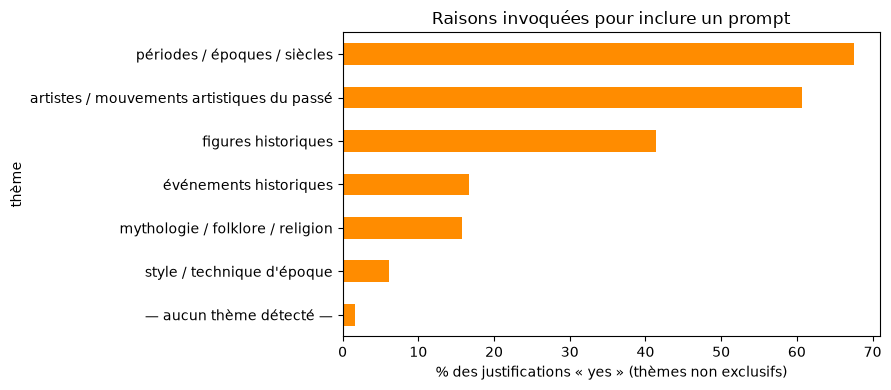

,nombre,part_des_yes
thème,,
périodes / époques / siècles,459086,67.6
artistes / mouvements artistiques du passé,412508,60.7
figures historiques,281248,41.4
événements historiques,113596,16.7
mythologie / folklore / religion,107224,15.8
style / technique d'époque,41767,6.1
— aucun thème détecté —,11845,1.7


In [9]:
# Typologie (ajustable) des raisons d'inclusion — thèmes non exclusifs
themes_yes = {
    "artistes / mouvements artistiques du passé": r"historical artists?|art movements?|art nouveau|impressionis|renaissance|baroque|ukiyo-?e|romanticis|pre-?raphaelite|realis[mt]",
    "périodes / époques / siècles": r"historical periods?|\beras?\b|centur(?:y|ies)|medieval|victorian|ancient|antiquity",
    "figures historiques": r"historical figures?|real-?life figures?",
    "événements historiques": r"historical events?|\bwars?\b|battle|revolution",
    "mythologie / folklore / religion": r"mytholog|folklore|biblical|legend|deit(?:y|ies)|religious",
    "style / technique d'époque": r"daguerr|vintage|retro|archival|old photograph|film still|sepia",
}
themes_yes_res = {name: re.compile(rx, re.IGNORECASE) for name, rx in themes_yes.items()}

n_yes = len(df_yes)
rows = []
matched_yes = pd.Series(False, index=df_yes.index)
for name, rx in themes_yes_res.items():
    hits = df_yes["raison"].str.contains(rx)
    rows.append({"thème": name, "nombre": int(hits.sum()),
                 "part_des_yes": round(100 * hits.mean(), 1)})
    matched_yes |= hits
rows.append({"thème": "— aucun thème détecté —", "nombre": int((~matched_yes).sum()),
             "part_des_yes": round(100 * (~matched_yes).mean(), 1)})

df_themes_yes = pd.DataFrame(rows).set_index("thème").sort_values("nombre", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
df_themes_yes["part_des_yes"].sort_values().plot.barh(ax=ax, color="darkorange")
ax.set_xlabel("% des justifications « yes » (thèmes non exclusifs)")
ax.set_title("Raisons invoquées pour inclure un prompt")
plt.tight_layout()
plt.show()

df_themes_yes

In [10]:
# Analyse lexicale des justifications « yes » (totalité, pas d'échantillonnage)
words_yes = Counter()
bigrams_yes = Counter()
for text in df_yes["raison"]:
    toks = [t for t in token_re.findall(text.lower()) if t not in STOP and len(t) > 2]
    words_yes.update(toks)
    bigrams_yes.update(zip(toks, toks[1:]))

pd.DataFrame({
    "mot": [w for w, _ in words_yes.most_common(25)],
    "fréq. mot": [c for _, c in words_yes.most_common(25)],
    "bigramme": [" ".join(b) for b, _ in bigrams_yes.most_common(25)],
    "fréq. bigramme": [c for _, c in bigrams_yes.most_common(25)],
})

,mot,fréq. mot,bigramme,fréq. bigramme
0,historical,1994785,note while,394983
1,while,456500,historical artists,231159
2,note,449992,historical figures,196793
3,art,427066,historical art,176377
4,artists,347519,art movements,133625
5,modern,268939,historical figure,121847
6,figures,222759,historical context,108559
7,century,217360,historical period,108321
8,tied,202718,historical periods,104110
9,era,201797,art nouveau,94905


In [11]:
# Lecture qualitative : quelques justifications « yes » tirées au hasard
with pd.option_context("display.max_colwidth", None):
    display(df_yes.sample(10, random_state=7)[["prompt", "raison"]])

,prompt,raison
166575,"realistic and very detailed beautiful photo portrait of Rembrandt standing in a Montmartre Alley, by Robert Doisneau, Leica SL2 35mm black and white","The prompt references **Rembrandt** (a historical figure) and **Montmartre** (a historical period/era in Paris) while also mentioning a famous photographer (**Robert Doisneau**) and a specific camera model tied to mid-20th-century photography.**\n\n*(Note: While ""Leica SL2"" is a modern camera, the historical context is reinforced by the reference to Rembrandt and Montmartre.)*"
533988,Michael Jackson is playing Tommy Wiseau's character in the film The Room,"The prompt references **Michael Jackson** (a historical figure in modern pop culture) and the fictional character **""Tommy Wiseau""** (a modern pop culture figure, but the film *The Room* is a cult classic with a cult following that ties into late 20th-century entertainment history). While Wiseau is not a historical figure, the context of Jackson’s portrayal of a fictional character in a cult film is rooted in **modern pop culture history**, which can be seen"
514522,"hyper realistic, insanity of the mind, schizophrenia, the human condition, inspired by silent hill, painted by keith thompson, caravaggio, masterpiece, artstation","This prompt references **historical artists (Caravaggio)** and **historical art movements/techniques (silent film era, hyper-realism as a stylistic evolution)**.\n\n*(Note: While ""inspired by"" can be subjective, the inclusion of Caravaggio—a key Baroque painter—and the nod to *Silent Hill* (a modern horror franchise with roots in psychological realism) ties into broader artistic and cultural historical influences.)*"
167080,"Richard Schmid and Jeremy Lipking portrait painting of A shield-maiden (Old Norse: skjoldmø [ˈskjɑldˌmɛːz̠]) was a female warrior from Scandinavian folklore and mythology. Shield-maidens are often mentioned in sagas such as Hervarar saga ok Heiðreks and in Gesta Danorum. They also appear in stories of other Germanic peoples: Goths, Cimbri, and Marcomanni.[1] The mythical Valkyries may have been based on such shield-maidens.[ full-figure","This prompt references **historical periods/eras (Scandinavian folklore, Germanic mythology)**, **historical sagas (Hervarar saga ok Heiðreks, Gesta Danorum)**, and **mythological figures (Shield-maidens, Valkyries)**—all tied to pre-Christian Germanic and Norse traditions.**\n\n*(Note: While ""Valkyries"" are often mythologized, their roots are explicitly tied to Norse/German"
651845,"Detailed maximalist portrait a Greek god with large lips and with large white eyes, exasperated expression, botany bones, HD mixed media, 3D collage, highly detailed and intricate, surreal illustration in the style of Caravaggio, dark art, baroque","The prompt references **Greek mythology** (Greek gods) and the **Baroque art movement** (Caravaggio’s influence), along with a historical artistic style (Baroque).]"
626489,"payday 2 characters in team fortress 2 concept art, by greg rutkowski, cinematic lighting, atmospheric, trending on artstation, ultra realistic, 4 k, octane render, real life characters, high detailed","This prompt references **historical figures** (e.g., *""real life characters""*) from *Payday 2*, a game set in a fictionalized but loosely inspired **post-apocalyptic 1980s–1990s** world that includes real-life historical elements (e.g., Cold War aesthetics, military themes).\n\n*(Note: While *Payday 2* itself is fictional, its art style and setting draw from historical influences"
123598,"ultra realistic red light camera capturing 2 1 savage running the light in san francisco, historically accurate footage, unreleased version of the second coming by james franco","The prompt references a fictional character (2 Savage) and a modern context (San Francisco), but it includes a historical reference to **""historically accurate footage""**—though this is vague—along with a nod to **""unreleased version of the Second Coming""*

## 4. Les prompts inclus eux-mêmes : de quel passé parle-t-on ?

On analyse maintenant le texte des ~680 000 prompts classés « yes » :
1. vocabulaire dominant (mots et bigrammes) ;
2. **périodisation** : quelles époques sont mobilisées (typologie par regex, ajustable) ;
3. **figures et artistes du passé** les plus cités ;
4. lecture qualitative.

Particularité des données : les chiffres y sont souvent espacés (« 1 9 2 0 s ») — on normalise donc les prompts avant analyse.

In [12]:
# Normalisation des prompts : minuscules + recollage des chiffres espacés (« 1 9 2 0 s » -> « 1920s »)
spaced_digits_re = re.compile(r"(?<=\d) (?=\d)")
df_yes["prompt_norm"] = (df_yes["prompt"].astype(str).str.lower()
                         .str.replace(spaced_digits_re, "", regex=True)
                         .str.replace(r"(?<=\d) (?=s\b)", "", regex=True))

# Vocabulaire dominant des prompts (stoplist adaptée : on retire le jargon « prompt engineering » générique)
STOP_PROMPTS = STOP | set("""highly detailed detail details intricate art artstation portrait painting style digital
realistic photorealistic hyperrealistic render rendering octane unreal engine concept lighting cinematic trending
quality resolution sharp focus close shot full body face beautiful""".split())

words_p = Counter()
bigrams_p = Counter()
for text in df_yes["prompt_norm"]:
    toks = [t for t in token_re.findall(text) if t not in STOP_PROMPTS and len(t) > 2]
    words_p.update(toks)
    bigrams_p.update(zip(toks, toks[1:]))

pd.DataFrame({
    "mot": [w for w, _ in words_p.most_common(30)],
    "fréq. mot": [c for _, c in words_p.most_common(30)],
    "bigramme": [" ".join(b) for b, _ in bigrams_p.most_common(30)],
    "fréq. bigramme": [c for _, c in bigrams_p.most_common(30)],
})

,mot,fréq. mot,bigramme,fréq. bigramme
0,greg,88263,alphonse mucha,70217
1,mucha,76171,greg rutkowski,60962
2,alphonse,70497,rutkowski alphonse,24967
3,oil,63086,karol bak,24959
4,rutkowski,62238,artgerm greg,24344
5,illustration,57426,greg hildebrandt,21663
6,gothic,50550,ayami kojima,21536
7,high,49372,mark brooks,20938
8,black,46166,jean delville,20645
9,photo,45726,neo gothic,19555


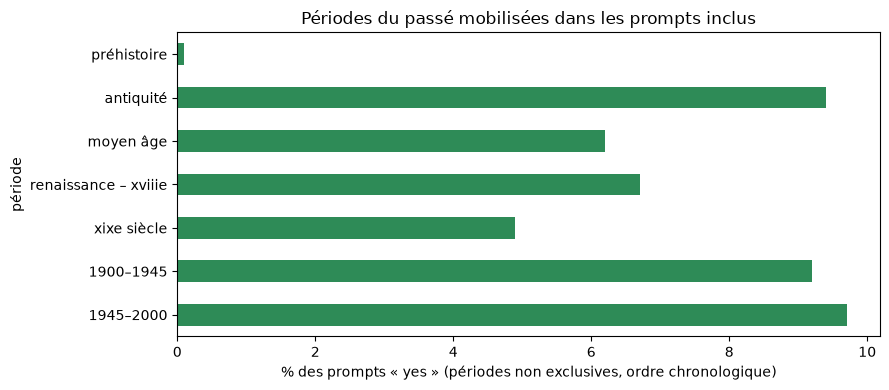

,nombre,part_des_yes
période,,
préhistoire,988,0.1
antiquité,63561,9.4
moyen âge,42072,6.2
renaissance – xviiie,45315,6.7
xixe siècle,33037,4.9
1900–1945,62712,9.2
1945–2000,65695,9.7


In [13]:
# Périodisation : quelles époques apparaissent dans les prompts inclus ?
# Typologie indicative et ajustable ; un prompt peut relever de plusieurs périodes.
periods = {
    "préhistoire": r"prehistor|stone age|neanderthal|caveman|cavemen",
    "antiquité": r"ancient|\brome\b|roman|greek|greece|egypt|pharaoh|caesar|gladiator|sparta|babylon|mesopotam|cleopatra|caligula|toga",
    "moyen âge": r"medieval|middle ages|knight|crusad|viking|byzantin|samurai|mongol",
    "renaissance – xviiie": r"renaissance|baroque|rococo|tudor|elizabethan|1[5-7]\d\d|1[5-7]th century|pirate|musketeer|colonial",
    "xixe siècle": r"victorian|18\d\d|19th century|napoleon|civil war|wild west|cowboy|steam ?engine|daguerr",
    "1900–1945": r"19[0-3]\ds|1940s|19[0-4]\d\b|world war|ww1|wwi\b|ww2|wwii|nazi|hitler|art deco|art nouveau|edwardian|trench",
    "1945–2000": r"19[5-9]\ds|19[5-9]\d\b|soviet|ussr|cold war|stalin|vietnam war|hippie|disco",
}
period_res = {name: re.compile(rx, re.IGNORECASE) for name, rx in periods.items()}

rows = []
for name, rx in period_res.items():
    hits = df_yes["prompt_norm"].str.contains(rx)
    rows.append({"période": name, "nombre": int(hits.sum()),
                 "part_des_yes": round(100 * hits.mean(), 1)})
df_periods = pd.DataFrame(rows).set_index("période")

fig, ax = plt.subplots(figsize=(9, 4))
df_periods["part_des_yes"].iloc[::-1].plot.barh(ax=ax, color="seagreen")
ax.set_xlabel("% des prompts « yes » (périodes non exclusives, ordre chronologique)")
ax.set_title("Périodes du passé mobilisées dans les prompts inclus")
plt.tight_layout()
plt.show()

df_periods

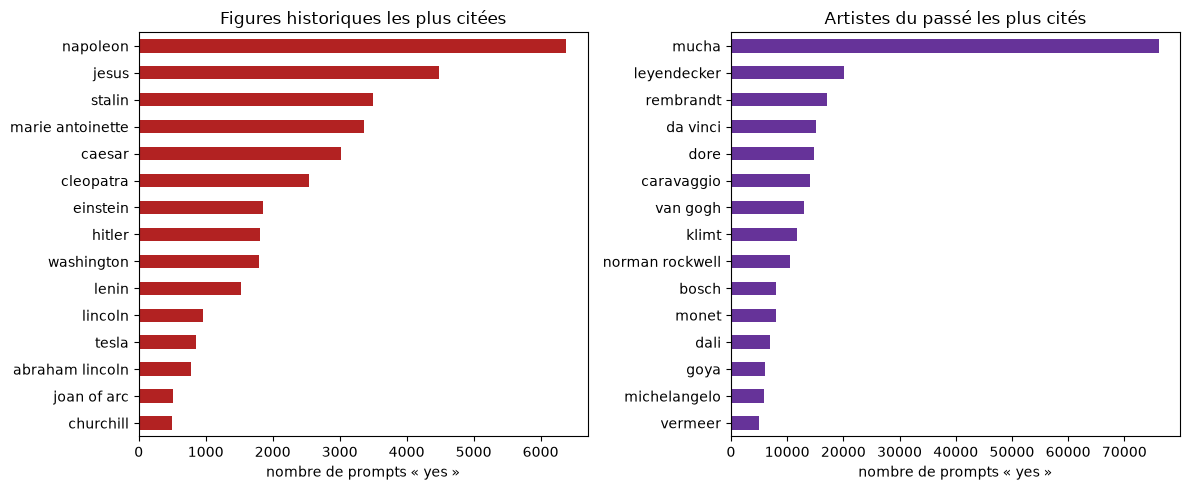

In [14]:
# Figures historiques et artistes du passé les plus cités dans les prompts inclus
FIGURES = ["napoleon", "hitler", "stalin", "lenin", "churchill", "lincoln", "washington",
           "caesar", "cleopatra", "genghis khan", "joan of arc", "marie antoinette",
           "queen victoria", "einstein", "tesla", "jesus", "buddha", "gandhi",
           "shakespeare", "mozart", "beethoven", "marilyn monroe", "elvis", "abraham lincoln"]
ARTISTES = ["van gogh", "mucha", "rembrandt", "monet", "picasso", "dali", "klimt",
            "caravaggio", "vermeer", "bosch", "hokusai", "dore", "da vinci", "michelangelo",
            "leyendecker", "waterhouse", "turner", "goya", "frazetta", "norman rockwell"]

def count_names(names):
    return (pd.Series({n: int(df_yes["prompt_norm"].str.contains(re.escape(n)).sum()) for n in names})
            .sort_values(ascending=False))

figures_counts = count_names(FIGURES)
artistes_counts = count_names(ARTISTES)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
figures_counts.head(15).iloc[::-1].plot.barh(ax=axes[0], color="firebrick")
axes[0].set_title("Figures historiques les plus citées")
artistes_counts.head(15).iloc[::-1].plot.barh(ax=axes[1], color="rebeccapurple")
axes[1].set_title("Artistes du passé les plus cités")
for ax in axes:
    ax.set_xlabel("nombre de prompts « yes »")
plt.tight_layout()
plt.show()

In [15]:
# Lecture qualitative : quelques prompts inclus tirés au hasard
with pd.option_context("display.max_colwidth", None):
    display(df_yes.sample(10, random_state=11)[["prompt"]])

,prompt
653075,"a large building with a clock on the top of it, a flemish baroque by bela ivanyi - grunwald, unsplash, heidelberg school, panorama, wimmelbilder, flemish baroque"
673908,uncle sam propaganda poster
172596,"balmy by david lachapelle vignetting. a experimental art of hercules after he has completed one of his twelve labors, the killing of the hydra. he is standing over the dead hydra, covered in blood clutching a sword that slew the beast. his face is expressionless."
548651,"realistic detailed face portrait of a beautiful futuristic italian renaissance queen in opulent alien glass armor by alphonse mucha, ayami kojima, amano, greg hildebrandt, and mark brooks, female, feminine, art nouveau, ornate italian renaissance cyberpunk, iridescent venetian blown glass, neo - gothic, gothic, character concept design"
595657,"A painting depicting the resurrection of Jesus Christ, (Jean Jules Linden), Peter Ilsted, (flowers), (monolith), (((Unreal Engine))), Religious painting,"
48127,baroque Greg Hildebrandt portrait
257903,Minsc from Baldur's gate
334042,a cute witch standing in a circle at the beginning of the world by greg rutkowski and frank frazetta and peter mohrbacher and william blake and dan mumford
595472,"realistic detailed face portrait of Claudia Schiffer by Alphonse Mucha, Ayami Kojima, Amano, Charlie Bowater, Karol Bak, Greg Hildebrandt, Jean Delville, and Mark Brooks, Art Nouveau, Neo-Gothic, gothic, rich deep moody colors"
60458,"sacagawea and captain america fight each other, native american comic book hero vs the first avenger, dramatic portrait, art by artgerm and tom bagshaw"


## 5. Topic modeling (LDA) des prompts inclus, croisé avec les périodes

On applique une LDA (scikit-learn, apprentissage *online*) sur les ~680 000 prompts « yes », puis on croise les topics obtenus avec la périodisation de la section 4 :
- pour chaque prompt, on retient son **topic dominant** ;
- pour chaque topic, on mesure la part de ses prompts qui mobilisent chaque période (heatmap **topics × périodes**).

Précautions d'interprétation :
- les prompts sont des textes courts, saturés de jargon (noms d'artistes, vocabulaire technique) : on s'attend à ce que des topics « stylistiques » (Mucha/Art Nouveau, Rutkowski/fantasy…) émergent à côté de topics « substantiels » (antiquité, guerres, portraits royaux…) — c'est précisément ce contraste qui nous intéresse ;
- le nombre de topics (`N_TOPICS`) est un choix : 15 par défaut, à faire varier.

In [16]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

N_TOPICS = 15

vectorizer = CountVectorizer(
    stop_words=list(ENGLISH_STOP_WORDS | STOP_PROMPTS),
    token_pattern=r"\b[a-z]{3,}\b",
    min_df=20,        # ignore les termes trop rares
    max_df=0.4,       # ...et trop fréquents
    max_features=30_000,
)
X = vectorizer.fit_transform(df_yes["prompt_norm"])
vocab = np.array(vectorizer.get_feature_names_out())
print(f"matrice documents-termes : {X.shape[0]:,} × {X.shape[1]:,}")

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    learning_method="online",
    batch_size=8192,
    max_iter=10,
    random_state=42,
    n_jobs=-1,
)
doc_topic = lda.fit_transform(X)
dominant = doc_topic.argmax(axis=1)
print("LDA entraînée.")

matrice documents-termes : 679,589 × 19,975


LDA entraînée.


In [17]:
# Mots-clés et taille de chaque topic
TOP_WORDS = 10

def topic_label(t, k=3):
    top = vocab[lda.components_[t].argsort()[::-1][:k]]
    return f"T{t:02d} " + " / ".join(top)

topic_sizes = pd.Series(dominant).value_counts().sort_index()
df_topics = pd.DataFrame({
    "mots-clés": [", ".join(vocab[lda.components_[t].argsort()[::-1][:TOP_WORDS]])
                  for t in range(N_TOPICS)],
    "prompts (topic dominant)": topic_sizes.values,
    "part (%)": (100 * topic_sizes / len(df_yes)).round(1).values,
}, index=[f"T{t:02d}" for t in range(N_TOPICS)])
df_topics.sort_values("prompts (topic dominant)", ascending=False)

,mots-clés,prompts (topic dominant),part (%)
T12,"photo, photography, old, photograph, oil, cent...",75424,11.1
T13,"movie, film, high, war, photo, world, photogra...",68962,10.1
T14,"greg, rutkowski, mucha, illustration, alphonse...",57444,8.5
T10,"rembrandt, vinci, leonardo, red, oil, renaissa...",56108,8.3
T05,"hair, black, white, young, long, elegant, much...",50054,7.4
T01,"craig, mullins, gaston, bussiere, leyendecker,...",49333,7.3
T04,"peter, oil, david, thomas, goya, landscape, fr...",48401,7.1
T07,"norman, rockwell, oil, lord, rings, painted, t...",44386,6.5
T08,"ernst, haeckel, movie, salvador, scene, dali, ...",38976,5.7
T02,"film, ultra, high, jan, napoleon, hyper, van, ...",37239,5.5


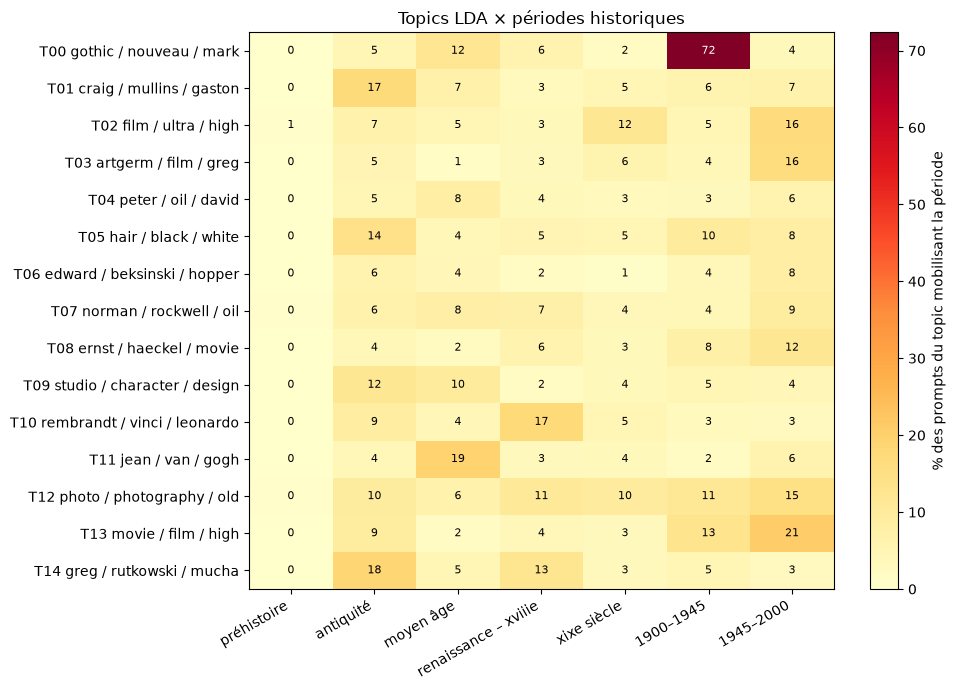

,préhistoire,antiquité,moyen âge,renaissance – xviiie,xixe siècle,1900–1945,1945–2000
T00 gothic / nouveau / mark,0.0,4.6,12.0,6.0,2.1,72.4,3.6
T01 craig / mullins / gaston,0.2,17.0,6.9,3.0,4.7,5.9,6.6
T02 film / ultra / high,0.5,6.6,5.0,3.4,11.7,4.8,16.4
T03 artgerm / film / greg,0.1,5.2,1.2,3.2,5.9,4.0,16.4
T04 peter / oil / david,0.0,4.6,8.4,3.5,2.9,3.1,6.1
T05 hair / black / white,0.0,14.2,4.0,5.1,4.9,10.0,8.4
T06 edward / beksinski / hopper,0.1,6.2,4.4,2.1,0.9,3.8,8.2
T07 norman / rockwell / oil,0.3,6.3,7.7,7.2,3.7,4.2,9.2
T08 ernst / haeckel / movie,0.0,4.1,2.5,6.0,3.4,7.5,11.9
T09 studio / character / design,0.0,11.7,10.1,2.0,3.6,5.0,4.3


In [18]:
# Croisement topics × périodes : pour chaque topic, % de ses prompts mobilisant chaque période
period_flags = pd.DataFrame({name: df_yes["prompt_norm"].str.contains(rx)
                             for name, rx in period_res.items()})

mat = np.zeros((N_TOPICS, len(periods)))
for t in range(N_TOPICS):
    mask = dominant == t
    mat[t] = 100 * period_flags[mask].mean().values

df_cross = pd.DataFrame(mat.round(1),
                        index=[topic_label(t) for t in range(N_TOPICS)],
                        columns=list(periods))

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(mat, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(periods)), labels=list(periods), rotation=30, ha="right")
ax.set_yticks(range(N_TOPICS), labels=[topic_label(t) for t in range(N_TOPICS)])
for t in range(N_TOPICS):
    for j in range(len(periods)):
        ax.text(j, t, f"{mat[t, j]:.0f}", ha="center", va="center",
                color="white" if mat[t, j] > mat.max() / 2 else "black", fontsize=8)
fig.colorbar(im, label="% des prompts du topic mobilisant la période")
ax.set_title("Topics LDA × périodes historiques")
plt.tight_layout()
plt.show()

df_cross

In [19]:
# Lecture qualitative : les 2 prompts les plus représentatifs de chaque topic
rows = []
for t in range(N_TOPICS):
    best = doc_topic[:, t].argsort()[::-1][:2]
    for i in best:
        rows.append({"topic": topic_label(t), "poids": round(doc_topic[i, t], 2),
                     "prompt": df_yes["prompt"].iloc[i][:300]})
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(rows).set_index("topic"))

,poids,prompt
topic,,
T00 gothic / nouveau / mark,0.99,"expressionistic decollage painting golden armor alien zombie horseman riding on a crystal bone dragon broken rainbow diamond maggot horse in a blossoming meadow full of colorful mushrooms and golden foil toad blobs in a golden sunset, distant forest horizon, painted by Mark Rothko, Helen Frankenthal"
T00 gothic / nouveau / mark,0.99,"expressionistic decollage painting golden armor alien zombie horseman riding on a crystal bone dragon broken rainbow diamond maggot horse in a blossoming meadow full of colorful mushrooms and golden foil toad blobs in a golden sunset, distant forest horizon, painted by Mark Rothko, Helen Frankenthal"
T01 craig / mullins / gaston,0.99,concept turnaround page of a psychic ethereal ghostly wraith like figure with a squid like parasite merged onto the side of its transparent skull and long tentacle arms that flow lazily but gracefully at its sides and act as a cloak while it floats around a frozen rocky tundra in the snow searching
T01 craig / mullins / gaston,0.99,concept turnaround page of a psychic ethereal ghostly wraith like figure with a squid like parasite merged onto the side of its transparent skull and long tentacle arms that flow lazily but gracefully at its sides and act as a cloak while it floats around a frozen rocky tundra in the snow searching
T02 film / ultra / high,0.98,"khyzyl saleem car : medium size: in the coronation of napoleon ceremony: in liquid : in dark plastic : 7, u, x, y, o graffiti big size forms: motherboard medium size forms : Kazimir Malevich big size forms : zaha hadid architecture big size forms: brutalist medium size forms: sci-fi futuristic set"
T02 film / ultra / high,0.98,"khyzyl saleem car : medium size: in the coronation of napoleon ceremony: in liquid : in dark plastic : 7, u, x, y, o graffiti big size forms: motherboard medium size forms : Kazimir Malevich big size forms : zaha hadid architecture big size forms: brutalist medium size forms: sci-fi futuristic set"
T03 artgerm / film / greg,0.98,"1985 two curvy women in a vintage kitchen baking a cake wearing an inflatable long prosthetic snout nose made of gooey pink slime, soft color wearing stripes sitting on chairs covered in soft fabric, pink slime everywhere, grey striped walls, studio lighting 1985 color film archival footage holding"
T03 artgerm / film / greg,0.98,"1973 two curvy women in a vintage kitchen baking a cake wearing an inflatable long prosthetic snout nose made of gooey pink slime, soft color wearing stripes sitting on chairs covered in soft fabric, pink slime everywhere, grey striped walls, studio lighting 1973 color film archival footage holding"
T04 peter / oil / david,0.98,"Earth by David Normal, Surrealism by David Normal, Eye of Providence by William Blake, william blake art exhibit, surrealism by James McCarthy, space station inside by Maksymilian Novak-Zempliński, Black Rainbow Opal, rainbow aura quartz, River by William Blake, oregon washington rain forest by jona"


## 6. Doublons et quasi-doublons : traces de « sessions » d'itération

Hypothèse : une partie des prompts très similaires et **proches dans le corpus** ont été écrits par la même personne, qui itérait sur son prompt pour obtenir une image un peu différente.

Trois analyses, sur **l'ensemble du corpus** (10,7 M de lignes, pas seulement les « yes ») :

1. **Doublons exacts** : volume, et distance entre occurrences d'un même prompt.
2. **Runs** : répétitions consécutives strictement identiques (compressées avant l'analyse de similarité).
3. **Quasi-doublons proches** : chaque prompt (représentant de run) est comparé aux `W = 5` suivants (ratio de Levenshtein, seuil 85/100, `rapidfuzz`) ; les paires sont chaînées en **sessions** par composantes connexes.

> ⚠️ **Note (établie en section 7)** : l'ordre des lignes de `full_results.csv` est *presque* celui de `prompts.csv` (99,9 % de correspondances monotones), mais la classification a introduit des brassages locaux par lots, sauté des lignes et strippé les prompts. La « proximité dans le fichier » utilisée ici reste donc un proxy approximatif ; **l'analyse de référence est celle de la section 7**, fondée sur les horodatages et canaux du corpus d'origine.

In [20]:
# 6.1 Doublons exacts sur tout le corpus : un hash par prompt, en streaming
hashes = []
for chunk in pd.read_csv(DATA_PATH, usecols=["prompt"], chunksize=CHUNK_SIZE):
    hashes.append(pd.util.hash_pandas_object(chunk["prompt"].astype(str), index=False).to_numpy())
h = np.concatenate(hashes)
del hashes
n_total = len(h)

uniq, inverse, counts = np.unique(h, return_inverse=True, return_counts=True)
n_unique = len(uniq)
print(f"{n_total:,} lignes, {n_unique:,} prompts uniques "
      f"→ {100 * (n_total - n_unique) / n_total:.1f} % des lignes sont des réoccurrences")

occ = pd.cut(pd.Series(counts), bins=[0, 1, 2, 5, 20, 100, np.inf],
             labels=["1 (unique)", "2", "3–5", "6–20", "21–100", "> 100"])
display(occ.value_counts().sort_index().to_frame("nb de prompts distincts"))

# Les prompts les plus dupliqués
top_idx = counts.argsort()[::-1][:5]
top_hashes = set(uniq[top_idx])
seen = {}
for chunk in pd.read_csv(DATA_PATH, usecols=["prompt"], chunksize=CHUNK_SIZE):
    hh = pd.util.hash_pandas_object(chunk["prompt"].astype(str), index=False).to_numpy()
    for k in np.nonzero(np.isin(hh, list(top_hashes - set(seen))))[0]:
        seen[hh[k]] = chunk["prompt"].iloc[k]
    if len(seen) == len(top_hashes):
        break
pd.DataFrame({"prompt": [str(seen[uniq[i]])[:160] for i in top_idx],
              "occurrences": counts[top_idx]})

10,670,393 lignes, 1,397,851 prompts uniques → 86.9 % des lignes sont des réoccurrences


,nb de prompts distincts
1 (unique),354873
2,116430
3–5,141617
6–20,743268
21–100,39608
> 100,2055


,prompt,occurrences
0,epic mask helmet robot ninja portrait stylized...,8244
1,fallout 7 6 retro futurist illustration art by...,5384
2,photo wallpaper sport car gran turismo 7 forza...,4105
3,cinematic bust portrait of psychedelic robot f...,4023
4,knight warrior helmet skyrim mask elder scroll...,2907


9,272,542 paires d'occurrences successives d'un même prompt
gap médian : 506,647 lignes
  gap ≤      1 : 0.4 %
  gap ≤     10 : 0.5 %
  gap ≤    100 : 0.5 %
  gap ≤ 10,000 : 2.9 %


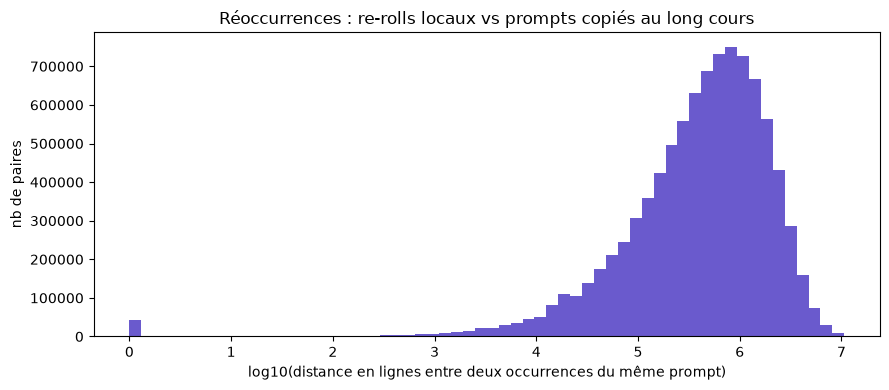

In [21]:
# 6.2 Distance entre deux occurrences successives d'un même prompt
# Petite distance -> probable re-roll du même utilisateur ; grande distance -> prompt copié/partagé.
order = np.lexsort((np.arange(n_total), inverse))
si, sp = inverse[order], np.arange(n_total)[order]
same = si[1:] == si[:-1]
gaps = (sp[1:] - sp[:-1])[same]
print(f"{len(gaps):,} paires d'occurrences successives d'un même prompt")
print(f"gap médian : {np.median(gaps):,.0f} lignes")
for seuil in [1, 10, 100, 10_000]:
    print(f"  gap ≤ {seuil:>6,} : {100 * (gaps <= seuil).mean():.1f} %")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log10(gaps), bins=60, color="slateblue")
ax.set_xlabel("log10(distance en lignes entre deux occurrences du même prompt)")
ax.set_ylabel("nb de paires")
ax.set_title("Réoccurrences : re-rolls locaux vs prompts copiés au long cours")
plt.tight_layout()
plt.show()

In [22]:
# 6.3 Quasi-doublons proches : détection des « sessions d'itération »
# (a) compression des répétitions consécutives identiques (runs)
# (b) comparaison de chaque run aux W suivants (rapidfuzz, ratio >= THRESH)
# (c) chaînage des paires en sessions (composantes connexes)
from rapidfuzz import fuzz
from rapidfuzz.process import cpdist

W, THRESH = 5, 85.0
ws_re = re.compile(r"\s+")

run_starts = []            # ligne de début de chaque run (ids globaux)
pair_a, pair_b, pair_s = [], [], []
run_texts = {}             # texte (tronqué) des runs impliqués dans une paire
tail_texts, tail_ids = [], []
carry_text = None          # texte du dernier run du chunk précédent
row_off = 0
n_runs = 0

for chunk in pd.read_csv(DATA_PATH, usecols=["prompt"], chunksize=CHUNK_SIZE):
    norm = (chunk["prompt"].astype(str).str.lower()
            .str.replace(spaced_digits_re, "", regex=True)
            .str.replace(ws_re, " ", regex=True).str.strip())
    arr = norm.to_numpy()
    prev = np.r_[[carry_text if carry_text is not None else "\x00"], arr[:-1]]
    new_run = np.nonzero(arr != prev)[0]
    run_starts.append(new_run + row_off)

    texts = [arr[i] for i in new_run]
    ids = list(range(n_runs, n_runs + len(texts)))
    full_t, full_i = tail_texts + texts, tail_ids + ids
    for k in range(1, W + 1):
        if len(full_t) <= k:
            continue
        scores = cpdist(full_t[:-k], full_t[k:], scorer=fuzz.ratio,
                        workers=-1, score_cutoff=THRESH)
        for idx in np.nonzero(scores)[0]:
            if idx + k < len(tail_ids):
                continue  # paire déjà vue au chunk précédent
            a, b = full_i[idx], full_i[idx + k]
            pair_a.append(a); pair_b.append(b); pair_s.append(scores[idx])
            run_texts.setdefault(a, full_t[idx][:250])
            run_texts.setdefault(b, full_t[idx + k][:250])

    n_runs += len(texts)
    tail_texts, tail_ids = full_t[-W:], full_i[-W:]
    carry_text = arr[-1]
    row_off += len(arr)

run_starts = np.concatenate(run_starts)
run_lens = np.diff(run_starts, append=n_total)
print(f"{n_runs:,} runs (répétitions consécutives compressées) pour {n_total:,} lignes")
print(f"{len(pair_a):,} paires de quasi-doublons à distance ≤ {W} runs (ratio ≥ {THRESH:.0f})")

display(pd.cut(pd.Series(run_lens), bins=[0, 1, 2, 5, 20, np.inf],
               labels=["1", "2", "3–5", "6–20", "> 20"])
        .value_counts().sort_index().to_frame("longueur des runs (lignes identiques consécutives)"))

10,628,847 runs (répétitions consécutives compressées) pour 10,670,393 lignes
2,984 paires de quasi-doublons à distance ≤ 5 runs (ratio ≥ 85)


,longueur des runs (lignes identiques consécutives)
1,10587413
2,41323
3–5,111
6–20,0
> 20,0


In [23]:
# 6.4 Chaînage des paires en sessions (union-find)
parent = {}

def find(x):
    while parent.setdefault(x, x) != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

for a, b in zip(pair_a, pair_b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

sessions = {}
for x in parent:
    sessions.setdefault(find(x), []).append(x)
sessions = {k: sorted(v) for k, v in sessions.items() if len(v) >= 2}

sizes = pd.Series([len(v) for v in sessions.values()])
n_runs_in_sessions = int(sizes.sum())
print(f"{len(sessions):,} sessions de quasi-doublons (≥ 2 runs)")
print(f"{n_runs_in_sessions:,} runs concernés, soit {100 * n_runs_in_sessions / n_runs:.1f} % des runs")
display(pd.cut(sizes, bins=[1, 2, 5, 10, 50, np.inf], labels=["2", "3–5", "6–10", "11–50", "> 50"])
        .value_counts().sort_index().to_frame("taille des sessions (en runs)"))

# lignes du corpus couvertes par une session (runs + leurs répétitions)
rows_in_sessions = int(sum(run_lens[r] for v in sessions.values() for r in v))
print(f"≈ {rows_in_sessions:,} lignes du corpus ({100 * rows_in_sessions / n_total:.1f} %) "
      f"appartiennent à une session de quasi-doublons proches")

2,972 sessions de quasi-doublons (≥ 2 runs)
5,954 runs concernés, soit 0.1 % des runs


,taille des sessions (en runs)
2,2962
3–5,10
6–10,0
11–50,0
> 50,0


≈ 5,986 lignes du corpus (0.1 %) appartiennent à une session de quasi-doublons proches


In [24]:
# 6.5 Lecture qualitative : quelques sessions d'itération (taille 3 à 8)
# On affiche les prompts dans l'ordre du corpus pour voir la dérive d'une itération à l'autre.
candidates = [v for v in sessions.values() if 3 <= len(v) <= 8]
print(f"{len(candidates):,} sessions de taille 3–8")

rng = np.random.default_rng(42)
for v in (candidates[i] for i in rng.choice(len(candidates), size=min(4, len(candidates)), replace=False)):
    print("—" * 100)
    for r in v:
        reps = f" (×{run_lens[r]})" if run_lens[r] > 1 else ""
        print(f"  ligne {run_starts[r]:>10,}{reps} : {run_texts.get(r, '?')}")

10 sessions de taille 3–8
————————————————————————————————————————————————————————————————————————————————————————————————————
  ligne  5,376,382 : face icon vector minimalist x - men, loftis, cory behance hd by jesper ejsing, by rhads, makoto shinkai and lois van baarle, ilya kuvshinov, rossdraws global illumination
  ligne  5,376,383 : face icon stylized minimalist agent 007, loftis, cory behance hd by jesper ejsing, by rhads, makoto shinkai and lois van baarle, ilya kuvshinov, rossdraws global illumination
  ligne  5,376,385 : hero world atari, behance hd by jesper ejsing, by rhads, makoto shinkai and lois van baarle, ilya kuvshinov, rossdraws global illumination
————————————————————————————————————————————————————————————————————————————————————————————————————
  ligne    644,909 : photography of arnold schoenberg, deep focus, d & d, fantasy, intricate, elegant, highly detailed, digital painting, artstation, concept art, matte, sharp focus, illustration, hearthstone, art by artgerm

### Vers la version robuste : le corpus d'origine

Tout ce qui précède repose sur un proxy (la proximité dans le fichier). Avec les métadonnées d'origine de DiffusionDB, la méthode devient directe :

1. joindre `full_results.csv` aux métadonnées (`user_name` hashé, `timestamp`) ;
2. regrouper par utilisateur, trier par horodatage ;
3. mesurer la similarité entre prompts **consécutifs du même utilisateur** (et l'écart temporel entre eux) ;
4. définir une session = suite de prompts du même utilisateur, similaires (ratio ≥ seuil) et rapprochés dans le temps (p. ex. < 30 min) ;
5. analyser ce qui change d'une itération à l'autre (mots ajoutés/retirés : sujets ? styles ? artistes ?) — en particulier pour les prompts « référant au passé ».

Colonnes nécessaires : `user_name`, `timestamp`, et une clé de jointure avec ce fichier (idéalement `image_name`, ou la garantie que l'ordre des lignes est identique).

## 7. Sessions d'itération avec le corpus d'origine (`prompts.csv`)

Le corpus original (scrape Discord de Stable Diffusion, format *open-prompts*, 11 Go, 10 778 778 lignes) fournit pour chaque ligne un JSON `raw_data` avec `timestamp`, `seed`, `cfg_scale`… mais **pas d'identifiant utilisateur**. L'URL Discord contient en revanche le **canal** (`attachments/<channel_id>/…`) où l'image a été générée.

Le proxy de session devient donc : **même canal Discord + proximité temporelle (< 30 min) + similarité textuelle (ratio ≥ 85)** — nettement plus solide que la proximité dans le fichier (section 6), même si plusieurs utilisateurs peuvent générer simultanément dans un même canal.

**Jointure.** `full_results.csv` n'est ni aligné ligne à ligne ni même dans le même ordre que `prompts.csv` : la classification a strippé les prompts, sauté des lignes (~108 000 vides, plus quelques cas comme `'1'`) et réécrit les résultats dans un ordre différent (lots parallèles). La jointure se fait donc par **(hash du prompt strippé, rang d'occurrence)** : la k-ième occurrence d'un prompt dans `full_results` ↔ sa k-ième occurrence dans `prompts.csv`. Exacte pour les prompts uniques ; pour les prompts dupliqués, les métadonnées peuvent être permutées entre occurrences du même texte (sans incidence sur le texte lui-même, et marginale sur l'analyse de sessions). La table est matérialisée dans `row_map.parquet` (−1 = non appariée).

Caches : `metadata.parquet` (timestamp, canal, seed) et `row_map.parquet`.

In [25]:
# 7.1 Métadonnées : extraction (mise en cache) + jointure (hash du prompt, rang d'occurrence)
META_CACHE = Path("metadata.parquet")
ROW_MAP_CACHE = Path("row_map.parquet")
PROMPTS_PATH = "prompts.csv"

if META_CACHE.exists():
    df_meta = pd.read_parquet(META_CACHE)
else:
    parts = []
    for chunk in pd.read_csv(PROMPTS_PATH, chunksize=500_000):
        raw = chunk["raw_data"].astype(str)
        parts.append(pd.DataFrame({
            "timestamp": pd.to_numeric(raw.str.extract(r'"timestamp": (\d+)', expand=False), errors="coerce"),
            "channel_id": pd.to_numeric(raw.str.extract(r'attachments/(\d+)/', expand=False), errors="coerce"),
            "seed": pd.to_numeric(raw.str.extract(r'"seed": (\d+)', expand=False), errors="coerce"),
        }))
    df_meta = pd.concat(parts, ignore_index=True)
    df_meta.to_parquet(META_CACHE)

if ROW_MAP_CACHE.exists():
    row_map = pd.read_parquet(ROW_MAP_CACHE)["prompt_row"].to_numpy()
else:
    # L'ordre des lignes diffère entre les deux fichiers (classification par lots) :
    # jointure par (hash du prompt strippé, rang d'occurrence). Exacte pour les prompts
    # uniques ; pour les dupliqués, la k-ième occurrence est appariée à la k-ième.
    def hash_col(path, strip=False):
        out = []
        for chunk in pd.read_csv(path, usecols=["prompt"], chunksize=1_000_000):
            s = chunk["prompt"].astype(str)
            out.append(pd.util.hash_pandas_object(s.str.strip() if strip else s,
                                                  index=False).to_numpy())
        return np.concatenate(out)

    hp, hf = hash_col(PROMPTS_PATH, strip=True), hash_col(DATA_PATH)
    dp = pd.DataFrame({"h": hp, "prompt_row": np.arange(len(hp), dtype=np.int64)})
    dp["k"] = dp.groupby("h").cumcount()
    dfr = pd.DataFrame({"h": hf, "fr_row": np.arange(len(hf), dtype=np.int64)})
    dfr["k"] = dfr.groupby("h").cumcount()
    m = dfr.merge(dp, on=["h", "k"], how="left")
    row_map = m.sort_values("fr_row")["prompt_row"].fillna(-1).to_numpy(dtype=np.int64)
    pd.DataFrame({"prompt_row": row_map}).to_parquet(ROW_MAP_CACHE)

# métadonnées alignées sur les lignes de full_results.csv (NaN si non appariée)
valid_map = row_map >= 0
safe = np.clip(row_map, 0, None)
ts = np.where(valid_map, df_meta["timestamp"].to_numpy(dtype="float64")[safe], np.nan)
ch = np.where(valid_map, df_meta["channel_id"].to_numpy(dtype="float64")[safe], np.nan)
print(f"{len(df_meta):,} lignes dans prompts.csv → {int(valid_map.sum()):,} / {len(row_map):,} "
      f"lignes de full_results appariées ({100 * valid_map.mean():.3f} %)")
print(f"timestamp manquant : {int(np.isnan(ts).sum()):,} ; canal manquant : {int(np.isnan(ch).sum()):,}")

10,778,778 lignes dans prompts.csv → 10,669,883 / 10,670,393 lignes de full_results appariées (99.995 %)
timestamp manquant : 849,564 ; canal manquant : 5,957


période couverte : 1970-01-02 22:06:26 → 2022-08-20 12:33:41
57 canaux Discord distincts


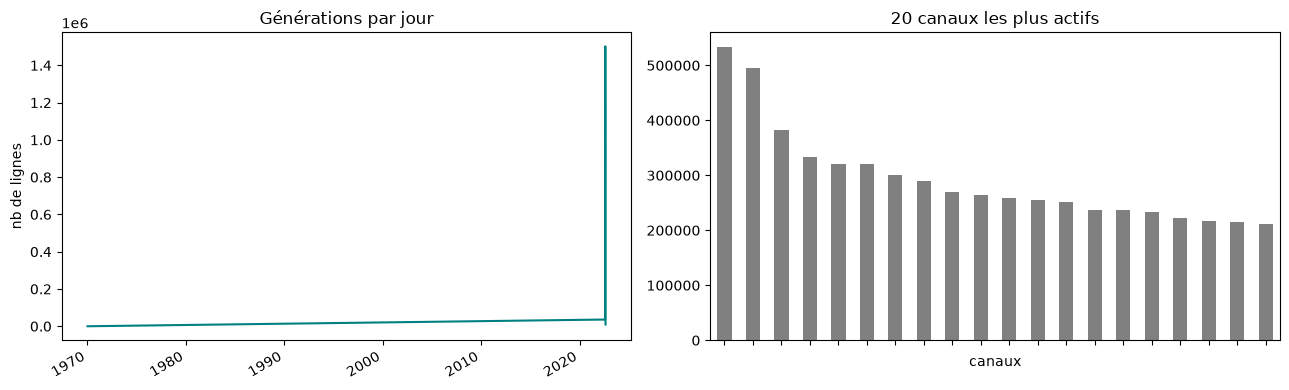

In [26]:
# 7.2 Temporalité et canaux du corpus (lignes alignées sur full_results)
dt_series = pd.to_datetime(pd.Series(ts), unit="s")
ch_series = pd.Series(ch)
print(f"période couverte : {dt_series.min()} → {dt_series.max()}")
print(f"{ch_series.nunique():,} canaux Discord distincts")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dt_series.dt.floor("D").value_counts().sort_index().plot(ax=axes[0], color="teal")
axes[0].set_title("Générations par jour")
axes[0].set_ylabel("nb de lignes")
ch_series.value_counts().head(20).plot.bar(ax=axes[1], color="gray")
axes[1].set_title("20 canaux les plus actifs")
axes[1].set_xticklabels([])
axes[1].set_xlabel("canaux")
plt.tight_layout()
plt.show()

In [27]:
# 7.3 Sessions « canal + temps + similarité »
# Tri par (canal, timestamp) ; chaque prompt est comparé aux W_T suivants du même canal
# à moins de DT_MAX secondes ; paires >= seuil chaînées en sessions.
W_T, THRESH_T, DT_MAX = 5, 85.0, 30 * 60
BATCH = 1_000_000

prompts_all = pd.read_csv(DATA_PATH, usecols=["prompt"],
                          dtype_backend="pyarrow")["prompt"]

def norm_batch(positions):
    s = prompts_all.iloc[positions].astype(str)
    return (s.str.lower()
             .str.replace(spaced_digits_re, "", regex=True)
             .str.replace(ws_re, " ", regex=True).str.strip()).tolist()

idx_sorted = np.lexsort((ts, ch))
ch_s, ts_s = ch[idx_sorted], ts[idx_sorted]

pa7, pb7, ps7 = [], [], []
for k in range(1, W_T + 1):
    dt = ts_s[k:] - ts_s[:-k]
    valid = np.nonzero((ch_s[k:] == ch_s[:-k]) & (dt >= 0) & (dt <= DT_MAX))[0]
    for s0 in range(0, len(valid), BATCH):
        v = valid[s0:s0 + BATCH]
        sc = cpdist(norm_batch(idx_sorted[v]), norm_batch(idx_sorted[v + k]),
                    scorer=fuzz.ratio, workers=-1, score_cutoff=THRESH_T)
        hit = np.nonzero(sc)[0]
        pa7.append(v[hit]); pb7.append(v[hit] + k); ps7.append(sc[hit])
    print(f"k={k} : {len(valid):,} paires candidates", flush=True)

pa7 = np.concatenate(pa7); pb7 = np.concatenate(pb7); ps7 = np.concatenate(ps7)
print(f"{len(pa7):,} paires similaires (même canal, Δt ≤ {DT_MAX // 60} min, ratio ≥ {THRESH_T:.0f})")

k=1 : 9,820,321 paires candidates


k=2 : 9,819,183 paires candidates


k=3 : 9,817,197 paires candidates


k=4 : 9,814,500 paires candidates


k=5 : 9,811,103 paires candidates


29,674,676 paires similaires (même canal, Δt ≤ 30 min, ratio ≥ 85)


1,126,695 sessions (≥ 2 générations similaires, même canal, Δt ≤ 30 min)
9,324,533 générations concernées, soit 87.4 % du corpus
durée médiane d'une session : 0.0 min ; moyenne : 0.2 min


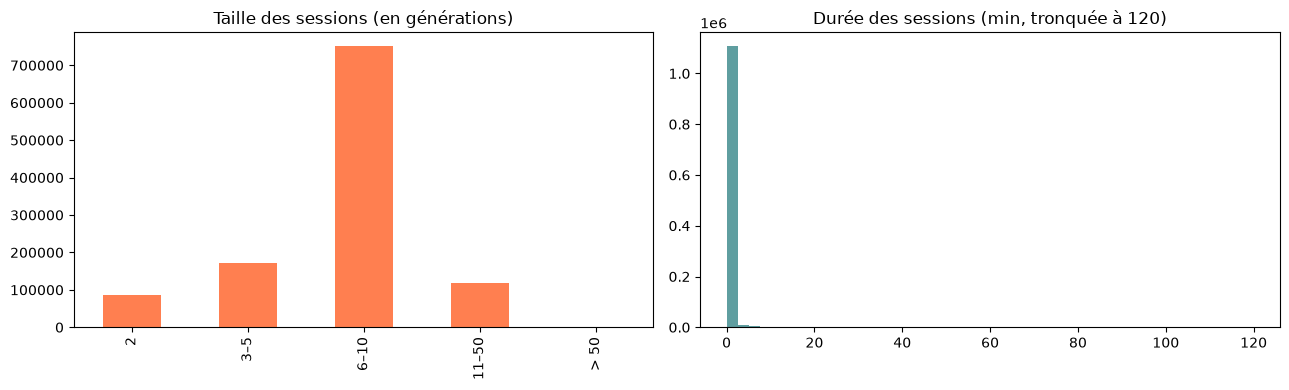

In [28]:
# 7.4 Chaînage en sessions et statistiques
parent7 = {}

def find7(x):
    while parent7.setdefault(x, x) != x:
        parent7[x] = parent7[parent7[x]]
        x = parent7[x]
    return x

for a, b in zip(pa7, pb7):
    ra, rb = find7(int(a)), find7(int(b))
    if ra != rb:
        parent7[rb] = ra

sessions7 = {}
for x in parent7:
    sessions7.setdefault(find7(x), []).append(x)
sessions7 = [sorted(v) for v in sessions7.values() if len(v) >= 2]

sizes7 = pd.Series([len(v) for v in sessions7])
durations = pd.Series([(ts_s[v[-1]] - ts_s[v[0]]) / 60 for v in sessions7])  # minutes
n_rows_in_sessions7 = int(sizes7.sum())
print(f"{len(sessions7):,} sessions (≥ 2 générations similaires, même canal, Δt ≤ 30 min)")
print(f"{n_rows_in_sessions7:,} générations concernées, soit {100 * n_rows_in_sessions7 / len(ts):.1f} % du corpus")
print(f"durée médiane d'une session : {durations.median():.1f} min ; moyenne : {durations.mean():.1f} min")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pd.cut(sizes7, bins=[1, 2, 5, 10, 50, np.inf], labels=["2", "3–5", "6–10", "11–50", "> 50"]) \
  .value_counts().sort_index().plot.bar(ax=axes[0], color="coral")
axes[0].set_title("Taille des sessions (en générations)")
axes[1].hist(durations.clip(upper=120), bins=48, color="cadetblue")
axes[1].set_title("Durée des sessions (min, tronquée à 120)")
plt.tight_layout()
plt.show()

In [29]:
# 7.5 Lecture qualitative : sessions avec variation (pas seulement des re-rolls identiques)
candidates7 = [v for v in sessions7 if 3 <= len(v) <= 10]
flat = np.array([p for v in candidates7 for p in v])
flat_txt = norm_batch(idx_sorted[flat])          # un seul gather vectorisé
bounds = np.cumsum([0] + [len(v) for v in candidates7])
sess_txts = [flat_txt[bounds[i]:bounds[i + 1]] for i in range(len(candidates7))]

varied = [i for i, t in enumerate(sess_txts) if len(set(t)) >= 3]  # ≥ 3 formulations distinctes
print(f"{len(varied):,} sessions de taille 3–10 avec ≥ 3 formulations distinctes "
      f"(sur {len(candidates7):,} sessions de cette taille)")

rng7 = np.random.default_rng(42)
for i in rng7.choice(varied, size=min(4, len(varied)), replace=False):
    v, txts = candidates7[i], sess_txts[i]
    print("—" * 110)
    t0 = ts_s[v[0]]
    for pos, txt in zip(v, txts):
        print(f"  +{(ts_s[pos] - t0) / 60:5.1f} min : {txt[:200]}")

7,274 sessions de taille 3–10 avec ≥ 3 formulations distinctes (sur 921,060 sessions de cette taille)
——————————————————————————————————————————————————————————————————————————————————————————————————————————————
  +  0.0 min : medieval young queen, rpg character, intricate, elegant, highly detailed, digital painting, artstation, concept art, smooth, sharp focus, illustration, art by artgerm and greg rutkowski and alphonse m
  +  3.2 min : medieval old king, rpg character, intricate, elegant, highly detailed, digital painting, artstation, concept art, smooth, sharp focus, illustration, art by artgerm and greg rutkowski and alphonse much
  +  4.2 min : medieval old queen, rpg character, intricate, elegant, highly detailed, digital painting, artstation, concept art, smooth, sharp focus, illustration, art by artgerm and greg rutkowski and alphonse muc
  +  5.3 min : medieval old goddess, rpg character, intricate, elegant, highly detailed, digital painting, artstation, concept art, smooth,

In [30]:
# 7.6 Ce qui change d'une itération à l'autre (paires avec variation, score < 100)
var_pairs = np.nonzero(ps7 < 100)[0]
print(f"{len(var_pairs):,} paires avec variation")
sample7 = (var_pairs if len(var_pairs) <= 300_000
           else np.random.default_rng(0).choice(var_pairs, size=300_000, replace=False))

added, removed = Counter(), Counter()
qa = norm_batch(idx_sorted[pa7[sample7]])
qb = norm_batch(idx_sorted[pb7[sample7]])
for a, b in zip(qa, qb):
    ta, tb = set(token_re.findall(a)), set(token_re.findall(b))
    added.update(tb - ta)
    removed.update(ta - tb)

pd.DataFrame({
    "token ajouté": [w for w, _ in added.most_common(25)],
    "fréq. ajout": [c for _, c in added.most_common(25)],
    "token retiré": [w for w, _ in removed.most_common(25)],
    "fréq. retrait": [c for _, c in removed.most_common(25)],
})

438,588 paires avec variation


,token ajouté,fréq. ajout,token retiré,fréq. retrait
0,a,9106,a,8712
1,in,8285,in,7050
2,the,7396,the,6603
3,of,6671,with,5896
4,with,6431,of,5645
5,and,5646,and,4884
6,an,4182,an,3823
7,portrait,4000,portrait,3384
8,on,3806,on,3221
9,as,3510,as,3186


In [31]:
# 7.7 Sessions et classification yes/no : la référence au passé survit-elle à l'itération ?
yes_l = []
for chunk in pd.read_csv(DATA_PATH, usecols=["references_past"], chunksize=1_000_000):
    yes_l.append((chunk["references_past"].astype(str).str.strip().str.lower() == "yes").to_numpy())
yes_mask = np.concatenate(yes_l)

flat_all = np.concatenate([np.array(v) for v in sessions7])
lens_all = np.array([len(v) for v in sessions7])
starts_all = np.r_[0, np.cumsum(lens_all)[:-1]]
vals = yes_mask[idx_sorted[flat_all]].astype(np.int64)
yes_per_session = np.add.reduceat(vals, starts_all)

in_sess_rate = vals.mean()
print(f"taux de « yes » : {100 * yes_mask.mean():.1f} % dans le corpus, "
      f"{100 * in_sess_rate:.1f} % dans les générations en session")

cat = np.select(
    [yes_per_session == 0, yes_per_session == lens_all],
    ["tout « no »", "tout « yes »"], default="mixte")
df_cat = pd.Series(cat).value_counts().to_frame("sessions")
df_cat["part (%)"] = (100 * df_cat["sessions"] / len(sessions7)).round(1)
display(df_cat)

mixte_with_yes = (cat == "mixte").sum() / max((yes_per_session > 0).sum(), 1)
print(f"parmi les sessions contenant au moins un « yes », {100 * mixte_with_yes:.1f} % sont mixtes :")
print("la classification bascule au sein d'une même session d'itération — à interpréter")
print("(itération qui historicise/déshistoricise le prompt, ou instabilité du classifieur sur quasi-doublons).")

taux de « yes » : 6.4 % dans le corpus, 6.2 % dans les générations en session


,sessions,part (%)
tout « no »,1054334,93.6
tout « yes »,69789,6.2
mixte,2572,0.2


parmi les sessions contenant au moins un « yes », 3.6 % sont mixtes :
la classification bascule au sein d'une même session d'itération — à interpréter
(itération qui historicise/déshistoricise le prompt, ou instabilité du classifieur sur quasi-doublons).


## 8. Sessions d'itération sur les prompts « yes » : re-rolls vs sessions d'écriture

On restreint l'analyse aux prompts classés « yes » et on sépare deux phénomènes :
- **re-roll** : regénération du même prompt à l'identique (texte inchangé, souvent Δt ≈ 0 — les lots de ~9 images d'un même message Discord) ;
- **session d'écriture** : l'utilisateur modifie le texte entre générations (≥ 2 formulations distinctes) — c'est là qu'on voit comment une représentation du passé est *retravaillée*.

Méthode :
1. extraction des **liens d'images** (`image_uri` Discord) depuis `prompts.csv`, cache `images.parquet` — chaque génération garde son lien, y compris les re-rolls ;
2. détection de sessions sur les seules lignes « yes » horodatées (même canal, Δt ≤ 30 min, ratio ≥ 85, fenêtre de 5) ;
3. au sein d'une session, découpage en **étapes** : les générations consécutives au texte identique forment une étape (re-rolls internes) ;
4. export d'une table **une ligne = une génération** (`yes_sessions.parquet`) : `session_id`, type de session, étape, horodatage, prompt, lien d'image — prête pour l'interprétation.

⚠️ Les URL `cdn.discordapp.com` datent de 2022 : Discord a depuis ajouté une expiration des liens ; elles valent surtout comme identifiants (canal/attachement) et peuvent nécessiter le proxy Discord pour être résolues.

In [32]:
# 8.1 Liens d'images : extraction depuis prompts.csv (cache images.parquet)
IMG_CACHE = Path("images.parquet")
if not IMG_CACHE.exists():
    parts = []
    for chunk in pd.read_csv(PROMPTS_PATH, usecols=["raw_data"], chunksize=500_000):
        parts.append(chunk["raw_data"].astype(str)
                     .str.extract(r'"image_uri": "(https[^"]+)"', expand=False))
    pd.DataFrame({"image_uri": pd.concat(parts, ignore_index=True)}).to_parquet(IMG_CACHE)

urls_all = pd.read_parquet(IMG_CACHE, dtype_backend="pyarrow")["image_uri"]
print(f"{urls_all.notna().sum():,} liens d'images sur {len(urls_all):,} lignes de prompts.csv")

def url_of(fr_rows):
    """liens d'images pour des lignes de full_results (via row_map ; '' si non apparié)"""
    rm = row_map[fr_rows]
    out = urls_all.iloc[np.clip(rm, 0, None)].astype(str).to_numpy()
    out[rm < 0] = ""
    return out

10,778,778 liens d'images sur 10,778,778 lignes de prompts.csv


In [33]:
# 8.2 Détection de sessions sur les seules lignes « yes » horodatées
yes_idx = np.nonzero(yes_mask & ~np.isnan(ts) & ~np.isnan(ch) & (ts > 1.6e9))[0]
print(f"{len(yes_idx):,} lignes « yes » exploitables "
      f"(sur {int(yes_mask.sum()):,} ; exclues : sans timestamp/canal ou timestamp aberrant)")

order_y = yes_idx[np.lexsort((ts[yes_idx], ch[yes_idx]))]
ts_y, ch_y = ts[order_y], ch[order_y]
texts_y = norm_batch(order_y)

W_Y, THRESH_Y, DT_MAX_Y = 5, 85.0, 30 * 60
pay, pby = [], []
for k in range(1, W_Y + 1):
    dt = ts_y[k:] - ts_y[:-k]
    valid = np.nonzero((ch_y[k:] == ch_y[:-k]) & (dt >= 0) & (dt <= DT_MAX_Y))[0]
    sc = cpdist([texts_y[i] for i in valid], [texts_y[i + k] for i in valid],
                scorer=fuzz.ratio, workers=-1, score_cutoff=THRESH_Y)
    hit = np.nonzero(sc)[0]
    pay.append(valid[hit]); pby.append(valid[hit] + k)
pay, pby = np.concatenate(pay), np.concatenate(pby)
print(f"{len(pay):,} paires similaires entre prompts « yes »")

parent8 = {}
def find8(x):
    while parent8.setdefault(x, x) != x:
        parent8[x] = parent8[parent8[x]]
        x = parent8[x]
    return x
for a, b in zip(pay, pby):
    ra, rb = find8(int(a)), find8(int(b))
    if ra != rb:
        parent8[rb] = ra
groups8 = {}
for x in parent8:
    groups8.setdefault(find8(x), []).append(x)
groups8 = [sorted(v) for v in groups8.values() if len(v) >= 2]
print(f"{len(groups8):,} groupes (≥ 2 générations « yes » liées)")

615,244 lignes « yes » exploitables (sur 679,589 ; exclues : sans timestamp/canal ou timestamp aberrant)


2,141,681 paires similaires entre prompts « yes »


55,733 groupes (≥ 2 générations « yes » liées)


In [34]:
# 8.3 Typage re-roll / écriture, découpage en étapes, table par génération + export
in_group = np.zeros(len(order_y), dtype=bool)
records = []
for sid, members in enumerate(groups8):
    in_group[members] = True
    mtexts = [texts_y[i] for i in members]
    stype = "écriture" if len(set(mtexts)) >= 2 else "re-roll pur"
    step, last = -1, None
    for i in members:
        if texts_y[i] != last:
            step += 1
            last = texts_y[i]
        records.append((sid, stype, step, i))

# les « yes » isolés (hors groupe) : générations uniques, sans re-roll ni réécriture détectés
solo = np.nonzero(~in_group)[0]
records += [(len(groups8) + j, "isolé", 0, int(i)) for j, i in enumerate(solo)]

rec = pd.DataFrame(records, columns=["session_id", "type_session", "etape", "pos_y"])
fr_rows = order_y[rec["pos_y"].to_numpy()]
df_sessions_yes = pd.DataFrame({
    "session_id": rec["session_id"],
    "type_session": rec["type_session"],
    "etape": rec["etape"],
    "fr_row": fr_rows,
    "datetime": pd.to_datetime(ts[fr_rows], unit="s"),
    "channel_id": ch[fr_rows].astype("int64"),
    "prompt": prompts_all.iloc[fr_rows].astype(str).to_numpy(),
    "image_uri": url_of(fr_rows),
}).sort_values(["session_id", "etape", "datetime"]).reset_index(drop=True)

df_sessions_yes.to_parquet("yes_sessions.parquet")
print(f"yes_sessions.parquet : {len(df_sessions_yes):,} générations « yes », "
      f"{df_sessions_yes['session_id'].nunique():,} sessions")
print(f"liens d'images présents : {(df_sessions_yes['image_uri'] != '').mean() * 100:.1f} %")
df_sessions_yes.head(8)

yes_sessions.parquet : 615,244 générations « yes », 78,406 sessions
liens d'images présents : 100.0 %


,session_id,type_session,etape,fr_row,datetime,channel_id,prompt,image_uri
0,0,re-roll pur,0,1043687,2022-08-06 21:07:44,1005505629126918144,lamar from gta5 as a classical painting,https://cdn.discordapp.com/attachments/1005505...
1,0,re-roll pur,0,2627014,2022-08-06 21:07:44,1005505629126918144,lamar from gta5 as a classical painting,https://cdn.discordapp.com/attachments/1005505...
2,1,re-roll pur,0,1769082,2022-08-06 21:12:37,1005505629126918144,"Art Deco, sometimes referred to as Deco, is a ...",https://cdn.discordapp.com/attachments/1005505...
3,1,re-roll pur,0,2267160,2022-08-06 21:12:37,1005505629126918144,"Art Deco, sometimes referred to as Deco, is a ...",https://cdn.discordapp.com/attachments/1005505...
4,1,re-roll pur,0,5325401,2022-08-06 21:12:37,1005505629126918144,"Art Deco, sometimes referred to as Deco, is a ...",https://cdn.discordapp.com/attachments/1005505...
5,1,re-roll pur,0,7642629,2022-08-06 21:12:37,1005505629126918144,"Art Deco, sometimes referred to as Deco, is a ...",https://cdn.discordapp.com/attachments/1005505...
6,1,re-roll pur,0,9195710,2022-08-06 21:12:37,1005505629126918144,"Art Deco, sometimes referred to as Deco, is a ...",https://cdn.discordapp.com/attachments/1005505...
7,1,re-roll pur,0,10187285,2022-08-06 21:12:37,1005505629126918144,"Art Deco, sometimes referred to as Deco, is a ...",https://cdn.discordapp.com/attachments/1005505...


,sessions,generations,taille_mediane,duree_mediane_min
type_session,,,,
isolé,22673,22673,1.0,0.0
re-roll pur,44262,369130,9.0,0.0
écriture,11471,223441,16.0,3.4


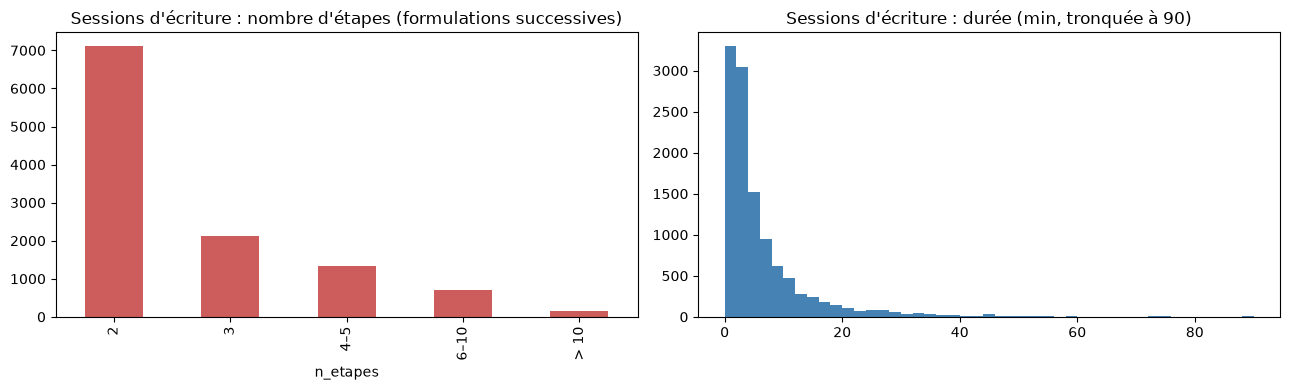

In [35]:
# 8.4 Statistiques : re-rolls purs vs sessions d'écriture
sess = df_sessions_yes.groupby("session_id").agg(
    type_session=("type_session", "first"),
    n_generations=("fr_row", "size"),
    n_etapes=("etape", "max"),
    duree_min=("datetime", lambda d: (d.max() - d.min()).total_seconds() / 60),
)
sess["n_etapes"] += 1

display(sess.groupby("type_session").agg(
    sessions=("n_generations", "size"),
    generations=("n_generations", "sum"),
    taille_mediane=("n_generations", "median"),
    duree_mediane_min=("duree_min", "median"),
).round(1))

ecr = sess[sess["type_session"] == "écriture"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pd.cut(ecr["n_etapes"], bins=[1, 2, 3, 5, 10, np.inf], labels=["2", "3", "4–5", "6–10", "> 10"]) \
  .value_counts().sort_index().plot.bar(ax=axes[0], color="indianred")
axes[0].set_title("Sessions d'écriture : nombre d'étapes (formulations successives)")
axes[1].hist(ecr["duree_min"].clip(upper=90), bins=45, color="steelblue")
axes[1].set_title("Sessions d'écriture : durée (min, tronquée à 90)")
plt.tight_layout()
plt.show()

In [36]:
# 8.5 Exemples de sessions d'écriture « yes », avec liens d'images
ecr_ids = sess[(sess["type_session"] == "écriture") & sess["n_etapes"].between(3, 8)].index
rng8 = np.random.default_rng(7)
for sid in rng8.choice(ecr_ids, size=min(3, len(ecr_ids)), replace=False):
    g = df_sessions_yes[df_sessions_yes["session_id"] == sid]
    t0 = g["datetime"].min()
    print("—" * 110)
    for etape, grp in g.groupby("etape"):
        dt0 = (grp["datetime"].min() - t0).total_seconds() / 60
        print(f"  étape {etape} (+{dt0:5.1f} min, ×{len(grp)} génération(s)) : "
              f"{grp['prompt'].iloc[0][:180]}")
        for u in grp["image_uri"].head(3):
            print(f"      {u[:110]}")

——————————————————————————————————————————————————————————————————————————————————————————————————————————————
  étape 0 (+  0.0 min, ×5 génération(s)) : yoshitaka amano blurred and dreamy realistic three quarter angle portrait of a young woman with black lipstick and black eyes wearing dress suit with tie, junji ito abstract patter
      https://cdn.discordapp.com/attachments/1005627987435192381/1007633382303346698/yoshitaka_amano_blurred_and_dre
      https://cdn.discordapp.com/attachments/1005627987435192381/1007633758708572262/yoshitaka_amano_blurred_and_dre
      https://cdn.discordapp.com/attachments/1005627987435192381/1007634221608738886/yoshitaka_amano_blurred_and_dre
  étape 1 (+ 20.4 min, ×4 génération(s)) : yoshitaka amano blurred and dreamy realistic three quarter angle portrait of a young woman with white hair and black eyes wearing dress suit with tie, junji ito abstract patterns i
      https://cdn.discordapp.com/attachments/1005627987435192381/1007638500478292018/yoshi

## 9. Interpréter les sessions « yes » : diffs, trajectoires, images

Quatre analyses :
1. **Ce qui change entre étapes** des sessions d'écriture « yes » : les tokens ajoutés/retirés sont catégorisés (artistes, période, figure historique, cadrage, jargon technique, attributs du sujet) ;
2. **Trajectoires yes/no** : on réintègre les voisins « no » des sessions mixtes (section 7) pour voir si une session *entre dans* ou *sort de* la référence au passé — et mesurer l'instabilité du classifieur sur textes identiques ;
3. **Récupération des images** : les liens Discord de 2022 sont morts (404). On joint chaque génération à **DiffusionDB** (même scrape, images hébergées sur Hugging Face) par `(seed, minute ± 1, décalage horaire +1 h)` — ~95 % de couverture ;
4. **Mosaïques** : une image-grille par session de re-roll (échantillon), les images étant extraites une à une des zips distants par requêtes HTTP *Range* (quelques Mo au lieu de 500 Mo par zip).

⚠️ Générer les mosaïques des **44 000** sessions de re-roll représenterait ~280 Go de transfert ; on illustre ici sur un échantillon, le code étant réutilisable pour toute session ciblée.

21,290 transitions entre étapes (33,954 étapes, 11,471 sessions d'écriture)


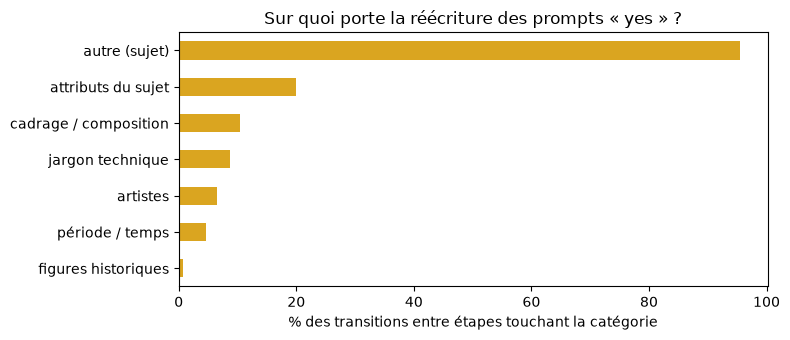

,transitions touchées (%),tokens les plus échangés
autre (sujet),95.4,"in, a, with, the, of, and, on, an"
attributs du sujet,20.0,"black, young, red, man, beautiful, white, woma..."
cadrage / composition,10.5,"portrait, face, full, body, close, head, shot,..."
jargon technique,8.7,"painting, art, detailed, realistic, light, con..."
artistes,6.5,"greg, mucha, rutkowski, jean, alphonse, vinci,..."
période / temps,4.6,"ancient, medieval, greek, egyptian, roman, bar..."
figures historiques,0.8,"napoleon, jesus, cleopatra, washington, caesar..."


In [37]:
# 9.1 Ce qui change entre étapes des sessions d'écriture « yes »
ART_TOKENS = set("""mucha rutkowski artgerm kojima amano bak hildebrandt delville brooks bowater
leyendecker bussiere mullins frazetta beksinski giger rembrandt caravaggio gogh vinci dore doré klimt
monet picasso dali hopper blake mumford mohrbacher wlop greg alphonse ayami karol gaston craig jean
gustave rossdraws tran kuvshinov repin shishkin aivazovsky moebius diterlizzi finlay waterhouse
turner goya rockwell norman magritte hokusai bosch vermeer leonardo michelangelo""".split())
FIGURE_TOKENS = set("""napoleon hitler stalin lenin churchill lincoln washington caesar cleopatra
einstein tesla jesus buddha gandhi shakespeare mozart beethoven elvis nefertiti caligula""".split())
CADRAGE_TOKENS = set("""portrait profile closeup close bust full body head shot angle wide view
front side face pose standing sitting symmetrical centered""".split())
JARGON_TOKENS = set("""detailed detail intricate artstation render octane unreal 4k 8k hd uhd
hyperrealistic realistic photorealistic cinematic trending sharp focus smooth masterpiece quality
resolution lighting light dramatic illustration painting digital art concept matte deviantart
cgsociety""".split())
ATTR_TOKENS = set("""black white red blue green yellow purple pink golden gold silver dark pale
young old man woman male female girl boy king queen hair eyes beard dress armor wearing beautiful
handsome cute elegant""".split())
PERIOD_TOKEN_RE = re.compile("|".join(periods.values()), re.IGNORECASE)

def categorize(tok):
    if tok in ART_TOKENS: return "artistes"
    if tok in FIGURE_TOKENS: return "figures historiques"
    if PERIOD_TOKEN_RE.search(tok): return "période / temps"
    if tok in CADRAGE_TOKENS: return "cadrage / composition"
    if tok in JARGON_TOKENS: return "jargon technique"
    if tok in ATTR_TOKENS: return "attributs du sujet"
    return "autre (sujet)"

def norm_txt(s):
    return ws_re.sub(" ", spaced_digits_re.sub("", str(s).lower())).strip()

ecriture = df_sessions_yes[df_sessions_yes["type_session"] == "écriture"]
steps = (ecriture.groupby(["session_id", "etape"])["prompt"].first()
         .map(norm_txt).reset_index())

trans_touch = Counter()
cat_tokens = {}
n_trans = 0
for sid, g in steps.groupby("session_id"):
    txts = g.sort_values("etape")["prompt"].tolist()
    for a, b in zip(txts, txts[1:]):
        ta, tb = set(token_re.findall(a)), set(token_re.findall(b))
        changed = (ta ^ tb)
        if not changed:
            continue
        n_trans += 1
        cats = set()
        for tok in changed:
            c = categorize(tok)
            cats.add(c)
            cat_tokens.setdefault(c, Counter())[tok] += 1
        trans_touch.update(cats)

df_diff = pd.DataFrame({
    "transitions touchées (%)": {c: round(100 * n / n_trans, 1) for c, n in trans_touch.items()},
    "tokens les plus échangés": {c: ", ".join(t for t, _ in cat_tokens[c].most_common(8))
                                  for c in trans_touch},
}).sort_values("transitions touchées (%)", ascending=False)
print(f"{n_trans:,} transitions entre étapes ({len(steps):,} étapes, "
      f"{steps['session_id'].nunique():,} sessions d'écriture)")

fig, ax = plt.subplots(figsize=(8, 3.5))
df_diff["transitions touchées (%)"].sort_values().plot.barh(ax=ax, color="goldenrod")
ax.set_xlabel("% des transitions entre étapes touchant la catégorie")
ax.set_title("Sur quoi porte la réécriture des prompts « yes » ?")
plt.tight_layout(); plt.show()
df_diff

In [38]:
# 9.2 Trajectoires yes/no dans les sessions mixtes (corpus complet, section 7)
mixte_sessions = []
for v in sessions7:
    labels = yes_mask[idx_sorted[np.array(v)]]
    if labels.any() and not labels.all():
        mixte_sessions.append(v)
print(f"{len(mixte_sessions):,} sessions mixtes (yes et no)")

flat_m = np.concatenate([np.array(v) for v in mixte_sessions])
txt_m = norm_batch(idx_sorted[flat_m])
bounds_m = np.cumsum([0] + [len(v) for v in mixte_sessions])

n_in, n_out, n_aller_retour, n_instable = 0, 0, 0, 0
examples = []
for i, v in enumerate(mixte_sessions):
    labels = yes_mask[idx_sorted[np.array(v)]]
    txts = txt_m[bounds_m[i]:bounds_m[i + 1]]
    # étapes = formulations distinctes consécutives ; label d'étape = vote majoritaire
    step_lab, step_txt, cur = [], [], None
    for t, l in zip(txts, labels):
        if t != cur:
            step_lab.append([]); step_txt.append(t); cur = t
        step_lab[-1].append(l)
    maj = [np.mean(ls) >= 0.5 for ls in step_lab]
    instable = any(0 < np.mean(ls) < 1 for ls in step_lab)
    if instable:
        n_instable += 1
    if len(set(maj)) == 1:
        continue  # mixité uniquement intra-étape = pure instabilité du classifieur
    if not maj[0] and maj[-1]:
        n_in += 1
        if len(examples) < 2 and 3 <= len(maj) <= 6:
            examples.append((step_txt, maj))
    elif maj[0] and not maj[-1]:
        n_out += 1
    else:
        n_aller_retour += 1

print(f"sessions avec étapes à l'identique mais labels divergents (instabilité) : {n_instable:,}")
print(f"trajectoires : entre dans le passé (no→yes) : {n_in:,} ; "
      f"en sort (yes→no) : {n_out:,} ; aller-retour : {n_aller_retour:,}")
for txts, maj in examples:
    print("—" * 100)
    for t, l in zip(txts, maj):
        print(f"  [{'YES' if l else ' no'}] {t[:150]}")

2,572 sessions mixtes (yes et no)


sessions avec étapes à l'identique mais labels divergents (instabilité) : 15
trajectoires : entre dans le passé (no→yes) : 1,069 ; en sort (yes→no) : 1,121 ; aller-retour : 367
————————————————————————————————————————————————————————————————————————————————————————————————————
  [ no] a portrait of female asa butterfield mixed with pam beesly, content, kind, slight smile, surrounded by plants, smaller eyes by gustav klimt
  [YES] a portrait of female asa butterfield mixed with pam beesly, content, kind, slight smile, glasses surrounded by plants, by gustav klimt
  [YES] a portrait of female asa butterfield mixed with pam beesly, content, kind, slight smile, beautiful eyes, longer eyebrows, surrounded by plants, by gus
  [YES] a portrait of female asa butterfield mixed with pam beesly, content, kind, slight smile, green eyes, longer eyebrows, surrounded by plants, by gustav 
————————————————————————————————————————————————————————————————————————————————————————————————————
  [ no] a br

In [39]:
# 9.3 Jointure avec DiffusionDB : retrouver les images (les liens Discord sont morts)
DDB_META = Path("diffusiondb_metadata.parquet")
if not DDB_META.exists():
    import urllib.request
    urllib.request.urlretrieve(
        "https://huggingface.co/datasets/poloclub/diffusiondb/resolve/main/metadata-large.parquet",
        DDB_META)

ddb = pd.read_parquet(DDB_META, columns=["image_name", "part_id", "seed", "timestamp"])
ddb_keys = pd.DataFrame({
    "seed": ddb["seed"].astype("int64"),
    "min": ddb["timestamp"].astype("datetime64[ns, UTC]").astype("int64") // (60 * 10**9),
    "image_name": ddb["image_name"], "part_id": ddb["part_id"]})
del ddb

pr_ys = row_map[df_sessions_yes["fr_row"].to_numpy()]
seeds_ys = df_meta["seed"].to_numpy()[np.clip(pr_ys, 0, None)]
ts_ys = df_meta["timestamp"].to_numpy()[np.clip(pr_ys, 0, None)]
base = pd.DataFrame({"seed": seeds_ys.astype("int64"),
                     "min0": (ts_ys.astype("int64") + 3600) // 60})
base.loc[pr_ys < 0, "seed"] = -1

res = pd.DataFrame({"image_name": pd.Series(pd.NA, index=base.index, dtype="object"),
                    "part_id": pd.Series(pd.NA, index=base.index, dtype="Int64")})
dk = ddb_keys.drop_duplicates(["seed", "min"])
for delta in [0, 1, -1]:  # décalage +1 h déjà appliqué ; tolérance d'arrondi de minute
    todo = res["image_name"].isna()
    o = base.loc[todo, ["seed"]].assign(min=base.loc[todo, "min0"] + delta)
    m = o.merge(dk, on=["seed", "min"], how="left")
    res.loc[todo, "image_name"] = m["image_name"].to_numpy()
    res.loc[todo, "part_id"] = m["part_id"].to_numpy()

df_sessions_yes["image_name"] = res["image_name"]
df_sessions_yes["part_id"] = res["part_id"]
df_sessions_yes.to_parquet("yes_sessions_images.parquet")
cov = df_sessions_yes["image_name"].notna().mean()
print(f"yes_sessions_images.parquet : {len(df_sessions_yes):,} générations, "
      f"{cov * 100:.1f} % appariées à une image DiffusionDB")

yes_sessions_images.parquet : 615,244 générations, 95.1 % appariées à une image DiffusionDB


In [40]:
# 9.4 Mosaïques : une grille d'images par session de re-roll (échantillon)
import fsspec, zipfile, io
from PIL import Image
from collections import defaultdict

rr = df_sessions_yes[(df_sessions_yes["type_session"] == "re-roll pur")
                     & df_sessions_yes["image_name"].notna()]
gp = {sid: g.drop_duplicates("image_name") for sid, g in rr.groupby("session_id")}
# sessions bien couvertes et concentrées sur peu de zips (limite le transfert)
cand = [sid for sid, g in gp.items()
        if g["image_name"].nunique() >= 6 and g["part_id"].nunique() <= 2]
rng9 = np.random.default_rng(5)
sel = list(rng9.choice(cand, size=min(9, len(cand)), replace=False))

Path("mosaiques").mkdir(exist_ok=True)
todo = [sid for sid in sel if not Path(f"mosaiques/session_{sid}.png").exists()]
print(f"{len(cand):,} sessions candidates ; échantillon : {sel} ; à générer : {todo}")

def part_url(pid):
    sub = 1 if pid <= 10_000 else 2
    return (f"https://huggingface.co/datasets/poloclub/diffusiondb/resolve/main/"
            f"diffusiondb-large-part-{sub}/part-{pid:06d}.zip")

need = defaultdict(list)
for sid in todo:
    for _, r in gp[sid].iterrows():
        need[int(r["part_id"])].append((sid, r["image_name"]))

fs = fsspec.filesystem("http", timeout=120)
imgs = defaultdict(list)
for pid, items in sorted(need.items()):
    for attempt in range(3):
        try:
            with fs.open(part_url(pid), "rb") as f, zipfile.ZipFile(f) as z:
                for sid, name in items:
                    try:
                        imgs[sid].append(Image.open(io.BytesIO(z.read(name))).convert("RGB"))
                    except KeyError:
                        pass
            print(f"part {pid} : {len(items)} images extraites", flush=True)
            break
        except Exception as e:
            print(f"part {pid} : tentative {attempt + 1} échouée ({type(e).__name__})", flush=True)
    else:
        print(f"part {pid} : abandonné", flush=True)

TH = 256
for sid in todo:
    pics = imgs[sid][:9]
    if not pics:
        continue
    cols = 3
    rows_n = int(np.ceil(len(pics) / cols))
    mosa = Image.new("RGB", (cols * TH, rows_n * TH), "white")
    for k, im in enumerate(pics):
        im.thumbnail((TH, TH))
        mosa.paste(im, ((k % cols) * TH + (TH - im.width) // 2,
                        (k // cols) * TH + (TH - im.height) // 2))
    mosa.save(f"mosaiques/session_{sid}.png")
print("mosaïques disponibles :", len(list(Path("mosaiques").glob("session_*.png"))))

101 sessions candidates ; échantillon : [np.int64(37106), np.int64(20780), np.int64(23509), np.int64(53447), np.int64(51694), np.int64(40111), np.int64(19725), np.int64(1645), np.int64(27937)] ; à générer : []
mosaïques disponibles : 9


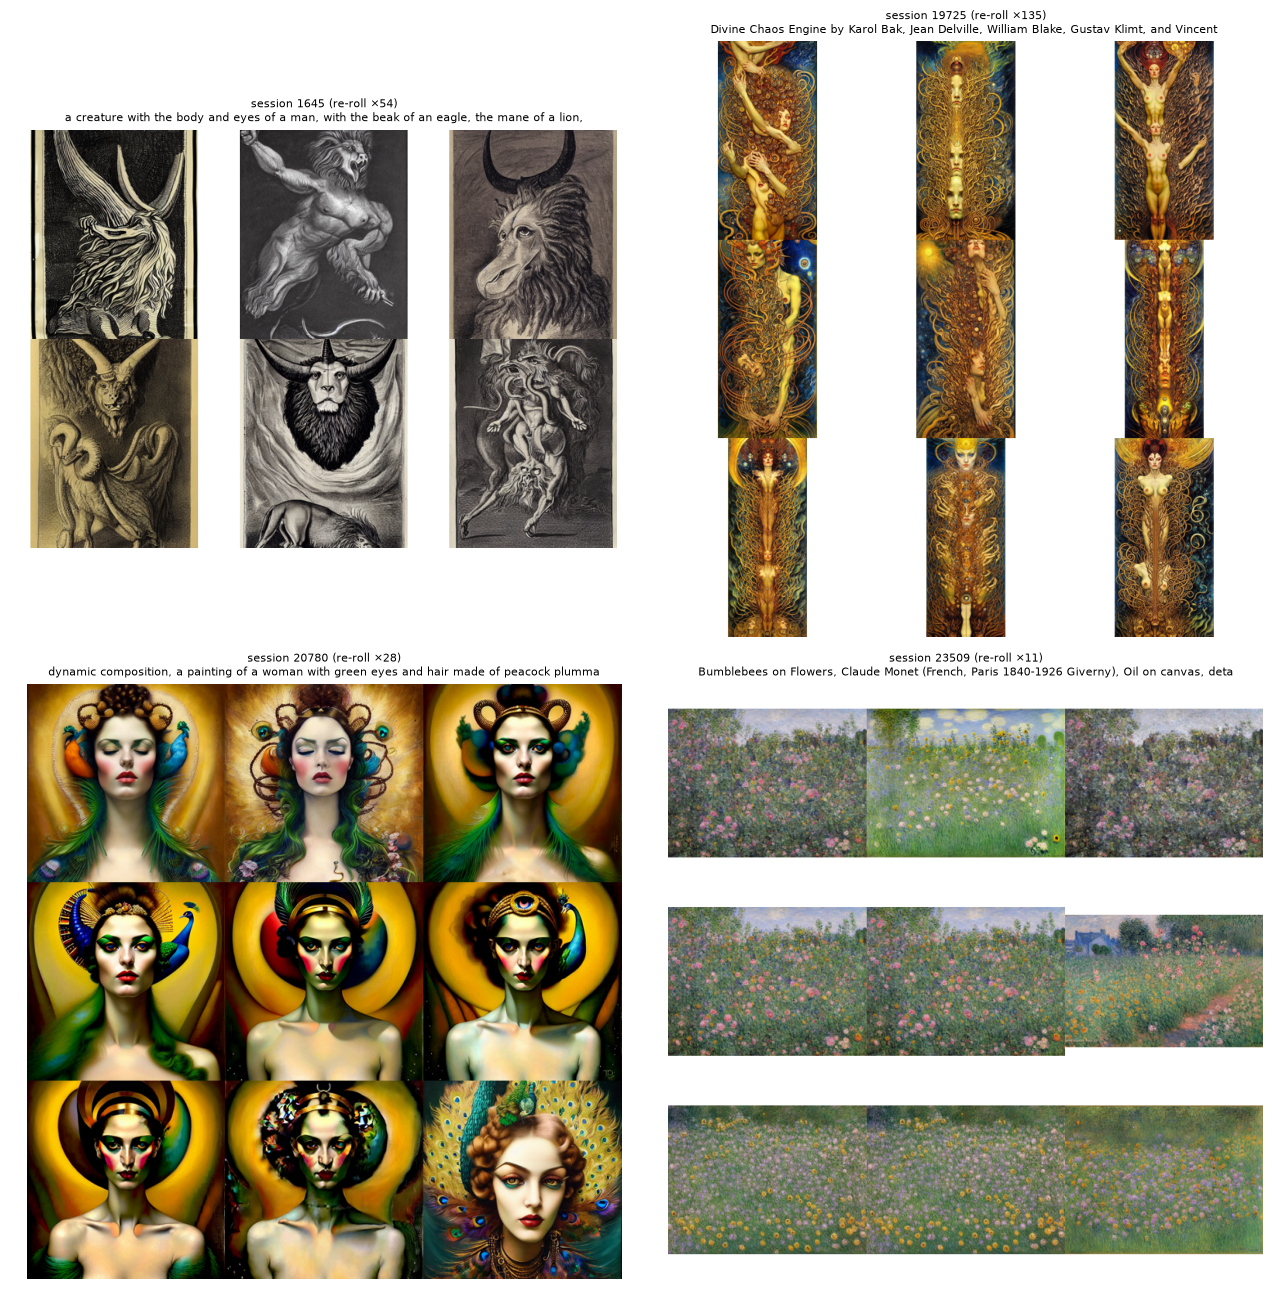

In [41]:
# 9.5 Affichage de quelques mosaïques (le prompt en titre)
import glob
files = sorted(glob.glob("mosaiques/session_*.png"))[:4]
fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, fp in zip(axes.flat, files):
    sid = int(fp.split("_")[-1].split(".")[0])
    g = df_sessions_yes[df_sessions_yes["session_id"] == sid]
    ax.imshow(plt.imread(fp))
    ax.set_title(f"session {sid} (re-roll ×{len(g)})\n{g['prompt'].iloc[0][:90]}", fontsize=8)
    ax.axis("off")
for ax in axes.flat[len(files):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 10. Quand c'est l'élément historique qui varie : esthétique vs contenu

Question : parmi les sessions d'écriture contenant au moins un « yes » (tout-yes ou mixtes), lesquelles font varier **l'élément historique** lui-même ? Et parmi celles-ci, lesquelles retravaillent le passé comme **contenu** (figure, civilisation, événement, période-cadre) plutôt que comme **esthétique** (artiste, style ou technique d'époque) ?

Méthode :
- pour chaque transition entre étapes (formulations distinctes successives), on isole les tokens échangés qui sont des **marqueurs historiques** ;
- chaque marqueur est rangé dans un registre : **esthétique** (artistes, styles/techniques d'époque) ou **contenu** (figures, peuples/civilisations, événements, termes de période) ;
- les tokens ambivalents (*baroque, renaissance, gothic, victorian, medieval, ancient*…) sont tranchés par le **contexte** (fenêtre de ±3 mots contenant *style, painting, art, by, photo, film*… → esthétique) ;
- export : `hist_variations.parquet`, une ligne par transition concernée (prompts avant/après, tokens échangés par registre, labels yes/no) — base de votre lecture qualitative.

Les lexiques sont volontairement explicites et ajustables : c'est une opérationnalisation discutable et discutée, pas une vérité terrain.

In [42]:
# 10.1 Lexiques des marqueurs historiques (ajustables)
STYLE_HIST_TOKENS = ART_TOKENS | set("""daguerreotype daguerrotype sepia tintype vintage retro
nouveau deco ukiyo ukiyoe impressionist impressionism expressionist expressionism romanticism
rococo raphaelite renaissance baroque gothic noir realism realist academism academic""".split())

CONTENT_HIST_TOKENS = FIGURE_TOKENS | set("""roman romans rome greek greeks greece egyptian egypt
pharaoh viking vikings norse samurai shogun knight knights crusade crusader crusades gladiator
spartan sparta persian babylonian sumerian mesopotamian aztec maya mayan inca celtic celt gaul
mongol ottoman byzantine prehistoric neolithic paleolithic caveman dinosaur antiquity ancient
medieval century centuries era dynasty empire emperor empress king queen tsar kaiser pope
war wars ww1 ww2 wwi wwii battle revolution siege trench soldier soldiers nazi soviet ussr
victorian edwardian colonial pirate musketeer cowboy western frontier castle armor armour
toga tunic peasant plague renaissance baroque gothic bc bce""".split())

AMBIGUOUS_TOKENS = {"renaissance", "baroque", "gothic", "victorian", "medieval", "ancient",
                    "antiquity", "edwardian", "colonial", "noir", "realism", "realist"}
STYLE_CONTEXT = set("""style styled painting paintings painted art artwork illustration drawing
photo photograph photography film movie aesthetic aesthetics inspired by oil canvas print poster
render engraving lithograph portrait""".split())

DECADE_RE = re.compile(r"^(1[0-9]{3}s?|[12]?[0-9](?:st|nd|rd|th))$")  # 1920s, 1850, 19th...

def hist_side(tok, context_tokens):
    """None si pas historique ; sinon 'esthétique' ou 'contenu'"""
    is_style = tok in STYLE_HIST_TOKENS
    is_content = tok in CONTENT_HIST_TOKENS or bool(DECADE_RE.match(tok))
    if not (is_style or is_content):
        return None
    if tok in AMBIGUOUS_TOKENS or (is_style and is_content):
        return "esthétique" if (context_tokens & STYLE_CONTEXT) else "contenu"
    return "esthétique" if is_style else "contenu"

def context_of(tok, toks, w=3):
    out = set()
    for i, t in enumerate(toks):
        if t == tok:
            out |= set(toks[max(0, i - w):i + w + 1])
    return out - {tok}

In [43]:
# 10.2 Détection : transitions où un marqueur historique change de part et d'autre
target_sessions = []
for v in sessions7:
    if yes_mask[idx_sorted[np.array(v)]].any():
        target_sessions.append(v)
print(f"{len(target_sessions):,} sessions contenant au moins un « yes »")

flat_t = np.concatenate([np.array(v) for v in target_sessions])
txt_t = norm_batch(idx_sorted[flat_t])
bounds_t = np.cumsum([0] + [len(v) for v in target_sessions])

rows10 = []
for i, v in enumerate(target_sessions):
    labels = yes_mask[idx_sorted[np.array(v)]]
    txts = txt_t[bounds_t[i]:bounds_t[i + 1]]
    # étapes = formulations distinctes consécutives (label = vote majoritaire)
    steps_t, steps_l, cur = [], [], None
    for t, l in zip(txts, labels):
        if t != cur:
            steps_t.append(t); steps_l.append([]); cur = t
        steps_l[-1].append(l)
    if len(steps_t) < 2:
        continue
    maj = [np.mean(ls) >= 0.5 for ls in steps_l]
    for s in range(len(steps_t) - 1):
        ta = token_re.findall(steps_t[s])
        tb = token_re.findall(steps_t[s + 1])
        sa, sb = set(ta), set(tb)
        changed = sa ^ sb
        hist_e, hist_c = [], []
        for tok in changed:
            ctx = context_of(tok, ta if tok in sa else tb)
            side = hist_side(tok, ctx)
            if side == "esthétique":
                hist_e.append(tok)
            elif side == "contenu":
                hist_c.append(tok)
        if hist_e or hist_c:
            rows10.append({
                "session_id7": i, "etape": s,
                "label_avant": "yes" if maj[s] else "no",
                "label_apres": "yes" if maj[s + 1] else "no",
                "hist_esthetique": " ".join(sorted(hist_e)),
                "hist_contenu": " ".join(sorted(hist_c)),
                "prompt_avant": steps_t[s][:400],
                "prompt_apres": steps_t[s + 1][:400],
            })

df_hist = pd.DataFrame(rows10)
df_hist.to_parquet("hist_variations.parquet")
print(f"{len(df_hist):,} transitions avec variation d'un marqueur historique "
      f"({df_hist['session_id7'].nunique():,} sessions) → hist_variations.parquet")

72,361 sessions contenant au moins un « yes »


1,589 transitions avec variation d'un marqueur historique (1,086 sessions) → hist_variations.parquet


In [44]:
# 10.3 Statistiques : registre de la variation historique
sess_reg = df_hist.groupby("session_id7").agg(
    contenu=("hist_contenu", lambda s: s.str.len().gt(0).any()),
    esthetique=("hist_esthetique", lambda s: s.str.len().gt(0).any()))
sess_reg["registre"] = np.select(
    [sess_reg["contenu"] & sess_reg["esthetique"],
     sess_reg["contenu"]],
    ["les deux", "contenu seul"], default="esthétique seule")

n_yes_sess = len(target_sessions)
print(f"sessions avec ≥ 1 « yes » et ≥ 2 formulations où l'élément historique varie : "
      f"{len(sess_reg):,}")
disp = sess_reg["registre"].value_counts().to_frame("sessions")
disp["part (%)"] = (100 * disp["sessions"] / len(sess_reg)).round(1)
display(disp)

# les marqueurs de contenu les plus échangés
cont_tokens = Counter(" ".join(df_hist["hist_contenu"]).split())
esth_tokens = Counter(" ".join(df_hist["hist_esthetique"]).split())
pd.DataFrame({
    "contenu échangé": [t for t, _ in cont_tokens.most_common(20)],
    "fréq.": [c for _, c in cont_tokens.most_common(20)],
    "esthétique échangée": [t for t, _ in esth_tokens.most_common(20)],
    "fréq. ": [c for _, c in esth_tokens.most_common(20)],
})

sessions avec ≥ 1 « yes » et ≥ 2 formulations où l'élément historique varie : 1,086


,sessions,part (%)
registre,,
contenu seul,516,47.5
esthétique seule,444,40.9
les deux,126,11.6


,contenu échangé,fréq.,esthétique échangée,fréq.
0,viking,132,ancient,93
1,ancient,59,mucha,69
2,medieval,57,medieval,57
3,queen,55,alphonse,57
4,egyptian,52,greg,52
5,roman,47,rutkowski,49
6,armor,47,klimt,32
7,king,44,rembrandt,32
8,castle,41,wlop,29
9,empire,38,giger,29


In [45]:
# 10.4 Lecture qualitative : sessions où le CONTENU historique varie
cont_trans = df_hist[df_hist["hist_contenu"].str.len() > 0]
print(f"{len(cont_trans):,} transitions « contenu » ; exemples :\n")
rng10 = np.random.default_rng(11)
for _, r in cont_trans.sample(8, random_state=11).iterrows():
    fl = f"[{r['label_avant']}→{r['label_apres']}]"
    print("—" * 100)
    print(f"{fl} échangé : {r['hist_contenu']}"
          + (f"   (esthétique aussi : {r['hist_esthetique']})" if r["hist_esthetique"] else ""))
    print(f"  avant : {r['prompt_avant'][:170]}")
    print(f"  après : {r['prompt_apres'][:170]}")

948 transitions « contenu » ; exemples :

————————————————————————————————————————————————————————————————————————————————————————————————————
[yes→yes] échangé : emperor napoleon
  avant : portrait of an polish man wearing a traditional nineteenth century polish empire military uniform, metal shoulder pauldrons, intricate, highly detailed, digital painting,
  après : portrait of emperor napoleon wearing a traditional nineteenth century french empire military uniform, metal shoulder pauldrons, intricate, highly detailed, digital painti
————————————————————————————————————————————————————————————————————————————————————————————————————
[yes→no] échangé : egyptian   (esthétique aussi : ancient)
  avant : small centered on watercolor paper, paint brush strokes, abstract watercolor painting of ancient egyptian potter, pottery, clay work, cinematic light, national romanticis
  après : small centered on watercolor paper, paint brush strokes, abstract watercolor painting of scandinavian potte

## 11. Export pour IRaMuTeQ

Trois corpus au format IRaMuTeQ (fichier texte UTF-8, chaque texte précédé d'une **ligne étoilée** `**** *variable_modalite …`, un prompt/justification = un texte) :
1. `iramuteq/corpus_explications_no.txt` — les justifications des « no » ;
2. `iramuteq/corpus_explications_yes.txt` — les justifications des « yes » ;
3. `iramuteq/corpus_prompts_yes_sessions.txt` — les prompts « yes » (pivots) **et** les prompts qui partagent une session avec un « yes » (voisins, parfois « no »).

**Plafonnement / échantillonnage.** `CAP_IRAMUTEQ = 100_000` plafonne chaque corpus (`None` = tout exporter). Méthode : **échantillonnage par réservoir** (algorithme R, Vitter 1985) — échantillon aléatoire uniforme de taille fixe en un seul passage, sans connaître le total, mémoire O(CAP), graine fixe (reproductible). Le corps des textes est nettoyé (retrait du marqueur `**NO**:`/`**[yes/no]:`, des astérisques réservés et des caractères de contrôle ; recollage des chiffres espacés « 1 9 2 0 » → « 1920 » pour les prompts).

Cette section réutilise les sessions calculées en section 7 (`sessions7`) — pas de recalcul. Le même code existe en scripts autonomes (`export_iramuteq_justifs.py`, `export_iramuteq_prompts.py`).

In [46]:
# 11.1 Paramètres et fonctions de formatage IRaMuTeQ
OUT_DIR = Path("iramuteq"); OUT_DIR.mkdir(exist_ok=True)
CAP_IRAMUTEQ = 100_000   # <-- plafond par corpus ; None pour tout exporter
SEED_IRAMUTEQ = 42

ctrl_re = re.compile(r"[\x00-\x1f\x7f]")     # contrôle / sauts de ligne
star_re = re.compile(r"\*+")                   # astérisques (réservés par IRaMuTeQ)
modality_re = re.compile(r"[^A-Za-z0-9_]+")

def clean_body(text):
    t = ctrl_re.sub(" ", str(text))
    t = star_re.sub(" ", t)
    return ws_re.sub(" ", t).strip()

def modality(value):
    return modality_re.sub("_", str(value)).strip("_") or "na"

def starred_line(**variables):
    return "**** " + " ".join(f"*{k}_{modality(v)}" for k, v in variables.items())

class ReservoirWriter:
    """Écrit un corpus IRaMuTeQ. Si cap est défini : échantillon par réservoir
    (algorithme R) en mémoire O(cap) ; sinon : écriture en flux direct."""
    def __init__(self, path, cap, seed):
        self.path, self.cap = path, cap
        self.rng = np.random.default_rng(seed)
        self.n = 0
        self.buf = [] if cap is not None else None
        self.fh = open(path, "w", encoding="utf-8") if cap is None else None
    def add(self, block):
        self.n += 1
        if self.cap is None:
            self.fh.write(block); return
        if len(self.buf) < self.cap:
            self.buf.append(block)
        else:
            j = int(self.rng.integers(0, self.n))
            if j < self.cap:
                self.buf[j] = block
    def close(self):
        if self.cap is None:
            self.fh.close()
        else:
            with open(self.path, "w", encoding="utf-8") as f:
                f.writelines(self.buf)
        return self.n

THEMES_NO = {
    "fictif":     r"fiction|fantasy|surreal|imaginar|myth|sci-?fi|futurist",
    "moderne":    r"modern|contemporary|present-day|current",
    "style":      r"stylistic|aesthetic|vintage|retro",
    "sanshisto":  r"no (?:reference|historical|specific)|without (?:any )?historical|lacks (?:any )?historical",
    "abstrait":   r"abstract|conceptual",
    "popculture": r"video ?game|anime|celebrit|pop[- ]?culture|movie|film|comic",
}
THEMES_YES = {
    "artistes":    r"historical artists?|art movements?|art nouveau|impressionis|renaissance|baroque|ukiyo-?e|romanticis|pre-?raphaelite|realis[mt]",
    "periodes":    r"historical periods?|\beras?\b|centur(?:y|ies)|medieval|victorian|ancient|antiquity",
    "figures":     r"historical figures?|real-?life figures?",
    "evenements":  r"historical events?|\bwars?\b|battle|revolution",
    "mytho":       r"mytholog|folklore|biblical|legend|deit(?:y|ies)|religious",
    "styleepoque": r"daguerr|vintage|retro|archival|old photograph|film still|sepia",
}

# terciles du temps de génération -> variable *gentime_court/moyen/long
_gt = pd.read_csv(DATA_PATH, usecols=["generation_time"], nrows=1_000_000)["generation_time"]
GT_Q1, GT_Q2 = float(_gt.quantile(1/3)), float(_gt.quantile(2/3))
def gentime_label(x):
    if not np.isfinite(x): return "na"
    return "court" if x < GT_Q1 else ("moyen" if x < GT_Q2 else "long")
print(f"terciles temps de génération : {GT_Q1:.3f}, {GT_Q2:.3f} s")

terciles temps de génération : 0.658, 0.768 s


In [47]:
# 11.2 Fichiers 1 & 2 : justifications « no » et « yes »
def export_justifs(which, themes, out_name):
    theme_res = {k: re.compile(v, re.IGNORECASE) for k, v in themes.items()}
    writer = ReservoirWriter(OUT_DIR / out_name, CAP_IRAMUTEQ, SEED_IRAMUTEQ)
    for chunk in pd.read_csv(DATA_PATH,
                             usecols=["references_past", "justification", "generation_time"],
                             chunksize=1_000_000):
        labels = chunk["references_past"].astype(str).str.strip().str.lower()
        sub = chunk[labels == which]
        for just, gt in zip(sub["justification"].astype(str), sub["generation_time"]):
            raison = prefix_re.sub("", just)
            body = clean_body(raison)
            if len(body) < 3:
                continue
            low = raison.lower()
            flags = {k: ("1" if r.search(low) else "0") for k, r in theme_res.items()}
            star = starred_line(classe=which, **flags, gentime=gentime_label(gt))
            writer.add(f"{star}\n{body}\n\n")
    total = writer.close()
    n_out = CAP_IRAMUTEQ if (CAP_IRAMUTEQ and total > CAP_IRAMUTEQ) else total
    print(f"[{which}] {total:,} justifications non vides ; {n_out:,} écrites -> {out_name}")

export_justifs("no",  THEMES_NO,  "corpus_explications_no.txt")
export_justifs("yes", THEMES_YES, "corpus_explications_yes.txt")

[no] 9,984,271 justifications non vides ; 100,000 écrites -> corpus_explications_no.txt


[yes] 679,589 justifications non vides ; 100,000 écrites -> corpus_explications_yes.txt


In [48]:
# 11.3 Fichier 3 : prompts « yes » + voisins de session (réutilise sessions7 de la section 7)
kept = [np.asarray(m) for m in sessions7 if yes_mask[idx_sorted[np.asarray(m)]].any()]
print(f"{len(sessions7):,} sessions ; {len(kept):,} contenant ≥ 1 « yes »")

all_pos = np.concatenate(kept) if kept else np.array([], dtype=int)
member_rows = idx_sorted[all_pos]
member_norm = norm_batch(member_rows)
row_to_sid, row_to_type = {}, {}
off = 0
for sid, m in enumerate(kept):
    rows = idx_sorted[m]
    norms = member_norm[off:off + len(m)]; off += len(m)
    stype = "reroll" if len(set(norms)) < 2 else "ecriture"
    for r in rows:
        row_to_sid[int(r)] = sid; row_to_type[int(r)] = stype

included = np.array(sorted(set(member_rows.tolist()) | set(np.nonzero(yes_mask)[0].tolist())))
print(f"{len(included):,} prompts (yes pivots + voisins + yes isolés)")

writer = ReservoirWriter(OUT_DIR / "corpus_prompts_yes_sessions.txt", CAP_IRAMUTEQ, SEED_IRAMUTEQ)
membership = []
raw = prompts_all.iloc[included].astype(str).to_numpy()
for r, prompt in zip(included, raw):
    body = clean_body(spaced_digits_re.sub("", prompt))
    if len(body) < 3:
        continue
    is_yes = bool(yes_mask[r])
    stype = row_to_type.get(int(r), "isole")
    classe = "yes" if is_yes else "no"
    role = "pivot" if is_yes else "voisin"
    writer.add(f"{starred_line(classe=classe, role=role, session=stype)}\n{body}\n\n")
    membership.append((int(r), row_to_sid.get(int(r), -1), stype, classe, role))

total = writer.close()
n_out = CAP_IRAMUTEQ if (CAP_IRAMUTEQ and total > CAP_IRAMUTEQ) else total
print(f"{total:,} prompts non vides ; {n_out:,} écrits -> corpus_prompts_yes_sessions.txt")
pd.DataFrame(membership, columns=["fr_row", "session_id", "session_type", "classe", "role"]) \
  .to_parquet("iramuteq_prompts_membership.parquet")

1,126,695 sessions ; 72,361 contenant ≥ 1 « yes »


695,509 prompts (yes pivots + voisins + yes isolés)


695,509 prompts non vides ; 100,000 écrits -> corpus_prompts_yes_sessions.txt


In [49]:
# 11.4 Contrôle : un texte = une ligne étoilée, et composition des corpus
import subprocess
for fn in ["corpus_explications_no.txt", "corpus_explications_yes.txt",
           "corpus_prompts_yes_sessions.txt"]:
    p = OUT_DIR / fn
    n = sum(1 for line in open(p, encoding="utf-8") if line.startswith("****"))
    print(f"{fn:42s} : {n:,} textes, {p.stat().st_size/1e6:.1f} Mo")

mb = pd.read_parquet("iramuteq_prompts_membership.parquet")
display(pd.crosstab(mb["role"], mb["session_type"]))

corpus_explications_no.txt                 : 100,000 textes, 30.6 Mo
corpus_explications_yes.txt                : 100,000 textes, 43.9 Mo
corpus_prompts_yes_sessions.txt            : 100,000 textes, 22.0 Mo


session_type,ecriture,isole,reroll
role,,,
pivot,38756,98300,542533
voisin,15778,0,142
